<a href="https://colab.research.google.com/github/ARISTOKRATIC/Commercial-Banking-Fraud-Mule-Account-and-Transaction-Laundering-Analytics/blob/main/T17_MuleWatch_v2_RealData_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SAS821S Security Analytics Capstone — T17: MuleWatch
Behavioural, Graph and NLP Analytics for Mule-Account and Transaction-Laundering Detection
Group: Member A — 221080457 · Romario Rhoman (Data and Modelling Lead) · Member B — 217150802 · Vaino Uusiku (Security Engineering and Intelligence Lead)

Topic: T17 — Commercial Banking Fraud, Mule-Account and Transaction-Laundering Analytics (fictional "MetroTrust Bank")

Data foundation
This notebook uses a hybrid real-and-synthetic data foundation. The transaction and account-graph backbone is real, public data — IBM's Anti-Money-Laundering transaction dataset (Kaggle ealtman2019/ibm-transactions-for-anti-money-laundering-aml, the HI-Small split), released under CDLA-Sharing-1.0 and documented in Altman et al., "Realistic Synthetic Financial Transactions for Anti-Money Laundering Models", NeurIPS 2023 Datasets and Benchmarks. No public dataset covers a bank's auth/MFA logs, device fingerprints, beneficiary-change history, KYC attributes or AML case notes — no institution publishes that, since it is exactly the internal, sensitive data no institution can release — so those five sources are synthetically generated, keyed onto the real account IDs from the IBM dataset, and cleaned in Section 2 alongside the real data

| Source | Origin in v2 |
|---|---|
| Transactions, account graph, laundering label, typology | **Real** — IBM AML (HI-Small), subsampled |
| Auth/MFA logs, devices, beneficiary changes, KYC, AML case notes | **Synthetic**, keyed to real account IDs |
| Account-takeover scenario | **Synthetic augmentation** — no public dataset covers this typology at all |

>

## 0. Setup

In [17]:
import os, json, random, string, datetime, hashlib, re, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import community as community_louvain
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (confusion_matrix, precision_score, recall_score,
                              f1_score, classification_report, accuracy_score,
                              precision_recall_curve, auc)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import shap
import spacy

RNG = np.random.default_rng(42)
random.seed(42)
pd.set_option("display.max_columns", 20)

BASE_DIR = "T17_MuleWatch"
for d in ["01_charter", "02_data/raw", "02_data/processed", "03_notebooks_or_scripts",
          "04_models", "05_simulation", "06_text_mining", "07_dashboard_or_prototype",
          "08_outputs", "09_documentation"]:
    os.makedirs(os.path.join(BASE_DIR, d), exist_ok=True)

NLP = spacy.load("en_core_web_sm")
print("Working folders ready under:", BASE_DIR)

Working folders ready under: T17_MuleWatch


## 1. Real transaction backbone — load, verify, and subsample the IBM AML dataset — *C1, C2*

The raw file (`HI-Small_Trans.csv`) is 5,078,345 transactions across 515,080 accounts spanning 18
days — far beyond what two people can iterate on for graph analytics and repeated model training on
personal laptops (Charter's stated compute assumption). It is also extremely imbalanced: only
**0.10%** of transactions are laundering-labelled. A **random** sample of that scale would very likely
contain zero or a handful of the rare positive cases — useless for a supervised/graph task. Instead we
use an **induced-subgraph sampling strategy**: keep every account genuinely involved in a laundering
transaction, add a sample of "retail-plausible" ordinary accounts (transaction degree 3–60 in the full
dataset — this deliberately excludes multi-hundred-thousand-transaction clearing/settlement accounts,
which are clearly not retail customers), and keep only transactions where **both** endpoints fall in
that account set. This guarantees **zero loss of the rare positive class** while bringing the dataset
down to a tractable, still-realistic size.

Once the file is uploaded, the previous cell will be modified to read it from the correct path.

In [18]:
raw_ibm = pd.read_csv("HI-Small_Trans.csv", dtype={"From Bank": str, "To Bank": str})
raw_ibm.columns = ["timestamp", "from_bank", "from_account", "to_bank", "to_account",
                    "amount_received", "receiving_currency", "amount_paid", "payment_currency",
                    "payment_format", "is_laundering"]
print(f"Raw IBM AML (HI-Small) file: {raw_ibm.shape[0]:,} transactions, "
      f"{pd.concat([raw_ibm.from_account, raw_ibm.to_account]).nunique():,} unique accounts, "
      f"{raw_ibm['is_laundering'].mean():.3%} laundering rate")

# --- Parse the companion typology-pattern file: real FATF-style laundering typologies ---
with open("Small_Patterns.txt") as f:
    pattern_text = f.read()
blocks = re.split(r"\r?\n\r?\n", pattern_text.strip())
pat_rows = []
for attempt_id, block in enumerate(blocks):
    lines = block.strip().split("\n")
    m = re.match(r"BEGIN LAUNDERING ATTEMPT - ([A-Z\-]+)", lines[0])
    if not m:
        continue
    pattern_type = m.group(1)
    for line in lines[1:]:
        if line.startswith("END"):
            continue
        parts = line.strip().split(",")
        if len(parts) == 11:
            pat_rows.append([attempt_id, pattern_type] + parts)
pat_df = pd.DataFrame(pat_rows, columns=["attempt_id", "pattern_type", "timestamp", "from_bank",
                       "from_account", "to_bank", "to_account", "amount_received", "receiving_currency",
                       "amount_paid", "payment_currency", "payment_format", "is_laundering"])

raw_ibm["amount_paid_str"] = raw_ibm["amount_paid"].apply(lambda v: f"{v:.2f}")
raw_ibm["match_key"] = (raw_ibm["timestamp"] + "|" + raw_ibm["from_account"] + "|" + raw_ibm["to_account"] +
                         "|" + raw_ibm["amount_paid_str"] + "|" + raw_ibm["payment_format"])
pat_df["match_key"] = (pat_df["timestamp"] + "|" + pat_df["from_account"] + "|" + pat_df["to_account"] + "|" +
                        pat_df["amount_paid"] + "|" + pat_df["payment_format"])
key_to_pattern = pat_df.drop_duplicates("match_key").set_index("match_key")["pattern_type"]
raw_ibm["typology"] = raw_ibm["match_key"].map(key_to_pattern)
raw_ibm.loc[(raw_ibm["is_laundering"] == 1) & raw_ibm["typology"].isna(), "typology"] = "UNSPECIFIED"
match_rate = (raw_ibm.loc[raw_ibm["is_laundering"] == 1, "typology"].notna()).mean()
print(f"Typology-pattern match rate against laundering-labelled rows: {match_rate:.1%}")
print(raw_ibm.loc[raw_ibm["is_laundering"] == 1, "typology"].value_counts())

Raw IBM AML (HI-Small) file: 5,078,345 transactions, 515,080 unique accounts, 0.102% laundering rate
Typology-pattern match rate against laundering-labelled rows: 100.0%
typology
UNSPECIFIED       1969
GATHER-SCATTER     716
SCATTER-GATHER     626
STACK              465
FAN-OUT            342
FAN-IN             318
CYCLE              287
BIPARTITE          263
RANDOM             191
Name: count, dtype: int64


In [19]:
laundering_accounts = set(raw_ibm.loc[raw_ibm.is_laundering == 1, "from_account"]) | \
                       set(raw_ibm.loc[raw_ibm.is_laundering == 1, "to_account"])
degree = pd.concat([raw_ibm["from_account"], raw_ibm["to_account"]]).value_counts()
retail_plausible = degree[~degree.index.isin(laundering_accounts) & (degree >= 3) & (degree <= 60)]

N_EXTRA_ACCOUNTS = 9000
extra_accounts = set(retail_plausible.sample(n=min(N_EXTRA_ACCOUNTS, len(retail_plausible)),
                                              random_state=42).index)
focus_accounts = laundering_accounts | extra_accounts
induced = raw_ibm["from_account"].isin(focus_accounts) & raw_ibm["to_account"].isin(focus_accounts)
real_txn = raw_ibm.loc[induced].drop(columns=["amount_paid_str", "match_key"]).reset_index(drop=True)

print(f"Focus accounts: {len(focus_accounts):,} ({len(laundering_accounts):,} laundering + "
      f"{len(extra_accounts):,} retail-plausible extra)")
print(f"Subsampled transactions: {real_txn.shape[0]:,} "
      f"(laundering preserved: {real_txn['is_laundering'].sum():,} / {raw_ibm['is_laundering'].sum():,}, "
      f"i.e. {real_txn['is_laundering'].sum() / raw_ibm['is_laundering'].sum():.1%})")
real_txn.head()

Focus accounts: 15,357 (6,357 laundering + 9,000 retail-plausible extra)
Subsampled transactions: 60,462 (laundering preserved: 5,177 / 5,177, i.e. 100.0%)


,timestamp,from_bank,from_account,to_bank,to_account,amount_received,receiving_currency,amount_paid,payment_currency,payment_format,is_laundering,typology
0,2022/09/01 00:02,012,8000F5030,012,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0,NaN
1,2022/09/01 00:08,001,8000EBAC0,001,8000EBAC0,14.26,US Dollar,14.26,US Dollar,Reinvestment,0,NaN
2,2022/09/01 00:17,01674,801009860,01674,801009860,17.29,US Dollar,17.29,US Dollar,Reinvestment,0,NaN
3,2022/09/01 00:03,003242,801DC7400,003242,801DC7400,1266.68,US Dollar,1266.68,US Dollar,Reinvestment,0,NaN
4,2022/09/01 00:14,010,800043990,010,800043990,23.63,US Dollar,23.63,US Dollar,Reinvestment,0,NaN


### 1.1 Account-level ground truth and the synthetic account-takeover overlay

The real data gives genuine laundering-account ground truth with 8 real typology sub-labels. It has
**no account-takeover scenario at all** — that typology does not exist in any public dataset, so it
is layered on synthetically: a small subset of the "extra" (non-laundering) real accounts is chosen,
given a synthetic anomalous-login + beneficiary-change narrative, and a synthetic payout transaction
is appended to the real transaction table in the *same schema*, clearly flagged so it is never
confused with genuine IBM data.

In [20]:
account_ids = sorted(focus_accounts)
N_ATO = 110
non_laundering_pool = list(extra_accounts)
random.shuffle(non_laundering_pool)
ato_accounts = set(non_laundering_pool[:N_ATO])

account_typology = {}
for a in account_ids:
    account_typology[a] = "legit"
for a in laundering_accounts:
    account_typology[a] = "mule_laundering"
for a in ato_accounts:
    account_typology[a] = "account_takeover"

print("Account-level ground truth (accounts, not transactions):")
print(pd.Series(account_typology).value_counts())

Account-level ground truth (accounts, not transactions):
legit               8890
mule_laundering     6357
account_takeover     110
Name: count, dtype: int64


In [21]:
start_ts = pd.to_datetime(real_txn["timestamp"]).min()
end_ts = pd.to_datetime(real_txn["timestamp"]).max()
window_days = (end_ts - start_ts).days + 1
foreign_currencies_for_payout = ["Bitcoin", "Ruble", "Yuan", "Rupee"]

synthetic_ato_rows = []
ato_takeover_ts = {}
ato_beneficiary_change_ts = {}
for acc in ato_accounts:
    takeover_ts = start_ts + pd.Timedelta(minutes=int(RNG.integers(0, 60 * 24 * (window_days - 1))))
    change_ts = takeover_ts + pd.Timedelta(minutes=int(RNG.integers(10, 240)))
    payout_ts = change_ts + pd.Timedelta(minutes=int(RNG.integers(5, 120)))
    ato_takeover_ts[acc] = takeover_ts
    ato_beneficiary_change_ts[acc] = change_ts
    new_beneficiary = f"SYNTHBEN{random.randint(900000, 999999)}"
    payout_amount = float(abs(RNG.normal(28000, 9000))) + 5000
    synthetic_ato_rows.append([
        payout_ts.strftime("%Y/%m/%d %H:%M"), "SYNTH", acc, "SYNTH", new_beneficiary,
        round(payout_amount, 2), random.choice(foreign_currencies_for_payout),
        round(payout_amount, 2), random.choice(foreign_currencies_for_payout), "Wire", 1
    ])

synthetic_ato_txn = pd.DataFrame(synthetic_ato_rows, columns=real_txn.columns.tolist()[:11] if
                                  len(real_txn.columns) >= 11 else real_txn.columns)
synthetic_ato_txn.columns = ["timestamp", "from_bank", "from_account", "to_bank", "to_account",
                              "amount_received", "receiving_currency", "amount_paid", "payment_currency",
                              "payment_format", "is_laundering"]
synthetic_ato_txn["typology"] = "ACCOUNT_TAKEOVER"
synthetic_ato_txn["is_synthetic"] = 1
real_txn["is_synthetic"] = 0

transactions_raw = pd.concat([real_txn, synthetic_ato_txn], ignore_index=True)
print(f"Appended {len(synthetic_ato_txn)} synthetic account-takeover payout transactions "
      f"(flagged is_synthetic=1) to the {len(real_txn)} real IBM transactions.")
print(f"Combined raw transaction table: {transactions_raw.shape}")

Appended 110 synthetic account-takeover payout transactions (flagged is_synthetic=1) to the 60462 real IBM transactions.
Combined raw transaction table: (60572, 13)


### 1.2 Synthetic layers keyed to the real account IDs — KYC, devices, auth/MFA, beneficiary changes, AML notes

These five sources have no public real-world equivalent, so they remain synthetically generated —
but every `account_id` below is a **real IBM account ID** from the subsampled population above, not
an invented one. Mule-ring-style device sharing is not injected here, since the mule/laundering
signal is entirely real, carried by the actual transaction graph — the only synthetic behavioural
injection is the account-takeover login/device/beneficiary narrative for the `ato_accounts` chosen
above.

In [22]:
risk_ratings = RNG.choice(["Low", "Medium", "High"], size=len(account_ids), p=[0.55, 0.35, 0.10])
occupations = RNG.choice(
    ["Salaried-Private", "Salaried-Public", "Self-Employed", "Student", "Retired", "SME-Owner"],
    size=len(account_ids), p=[0.35, 0.15, 0.20, 0.10, 0.08, 0.12])
onboard_start = start_ts - pd.Timedelta(days=int(RNG.integers(30, 900)))
onboarding_dates = [onboard_start + datetime.timedelta(days=int(RNG.integers(0, 900))) for _ in account_ids]
home_countries = RNG.choice(["Namibia", "South Africa", "Botswana"], size=len(account_ids), p=[0.8, 0.15, 0.05])
account_home_country = dict(zip(account_ids, home_countries))

kyc = pd.DataFrame({
    "account_id": account_ids, "risk_rating": risk_ratings, "onboarding_date": onboarding_dates,
    "occupation_category": occupations,
    "typology_ground_truth": [account_typology[a] for a in account_ids],
})
print("KYC profiles built for all", len(kyc), "focus accounts (real IDs).")
kyc.head()

KYC profiles built for all 15357 focus accounts (real IDs).


,account_id,risk_rating,onboarding_date,occupation_category,typology_ground_truth
0,100428660,Medium,2022-12-22,SME-Owner,mule_laundering
1,1004286A8,Medium,2022-07-19,Student,mule_laundering
2,1004286F0,Low,2022-08-15,Salaried-Private,mule_laundering
3,100428738,Low,2024-01-23,Salaried-Public,mule_laundering
4,100428780,Low,2022-02-24,Salaried-Public,mule_laundering


In [23]:
N_DEVICES = 20000
device_os = RNG.choice(["Android", "iOS", "Windows", "macOS"], size=N_DEVICES, p=[0.5, 0.3, 0.15, 0.05])
device_browser = RNG.choice(["ChromeMobile", "Safari", "Chrome", "Edge", "Firefox"], size=N_DEVICES)
device_first_seen = [onboard_start + datetime.timedelta(days=int(RNG.integers(0, 900))) for _ in range(N_DEVICES)]
device_hashes = [hashlib.sha256(f"dev-{i}-{random.random()}".encode()).hexdigest()[:16] for i in range(N_DEVICES)]
devices = pd.DataFrame({"device_hash": device_hashes, "os": device_os, "browser": device_browser,
                         "first_seen": device_first_seen})
devices["last_seen"] = devices["first_seen"] + pd.to_timedelta(RNG.integers(30, 700, size=N_DEVICES), unit="D")

device_pool = list(devices["device_hash"])
random.shuffle(device_pool)
pool_ptr = 0
account_primary_devices = {}
for a in account_ids:
    n = 1 if account_typology[a] == "legit" else int(RNG.choice([1, 2], p=[0.85, 0.15]))
    assigned = device_pool[pool_ptr:pool_ptr + n]
    pool_ptr += n
    account_primary_devices[a] = assigned if assigned else [device_pool[-1]]
print("devices:", devices.shape)

devices: (20000, 5)


In [24]:
N_AUTH_PER_ACCOUNT = 4
foreign_countries = ["Russia", "Nigeria", "Vietnam", "Brazil", "Ukraine", "Pakistan"]
auth_rows = []
for i, acc in enumerate(account_ids):
    n_events = max(1, int(RNG.poisson(N_AUTH_PER_ACCOUNT)))
    for k in range(n_events):
        ts = start_ts + pd.Timedelta(minutes=int(RNG.integers(0, 60 * 24 * window_days)))
        is_takeover_event = (account_typology[acc] == "account_takeover" and k == 0)
        if is_takeover_event:
            ts = ato_takeover_ts[acc]
            device_id = random.choice(device_pool)
            country = random.choice(foreign_countries)
            mfa_result = RNG.choice(["failed", "not_completed", "passed"], p=[0.45, 0.30, 0.25])
            login_result = RNG.choice(["success", "fail"], p=[0.65, 0.35])
            hour = int(RNG.integers(0, 4))
            ts = ts.replace(hour=hour)
        else:
            device_id = random.choice(account_primary_devices[acc])
            country = account_home_country[acc]
            mfa_result = RNG.choice(["passed", "failed"], p=[0.94, 0.06])
            login_result = RNG.choice(["success", "fail"], p=[0.96, 0.04])
            hour = ts.hour
        off_hours = int(hour < 6 or hour > 22)
        auth_rows.append([f"A{len(auth_rows):07d}", acc, ts, device_id, country, mfa_result, login_result,
                           off_hours, int(is_takeover_event)])

auth_logs = pd.DataFrame(auth_rows, columns=["event_id", "account_id", "timestamp", "device_id",
                          "geo_country", "mfa_result", "login_result", "off_hours_flag",
                          "anomaly_label_synthetic"])
print("auth_logs:", auth_logs.shape)

auth_logs: (61640, 9)


In [25]:
ben_rows = []
for acc, change_ts in ato_beneficiary_change_ts.items():
    ben_rows.append([acc, f"OLDBEN{random.randint(100000,199999)}",
                      f"SYNTHBEN{random.randint(900000,999999)}", change_ts, "internet_banking", 1])
n_background = 6000
for _ in range(n_background):
    acc = random.choice(account_ids)
    ts = start_ts + pd.Timedelta(minutes=int(RNG.integers(0, 60 * 24 * window_days)))
    ben_rows.append([acc, f"OLDBEN{random.randint(100000,199999)}", f"NEWBEN{random.randint(400000,499999)}",
                      ts, random.choice(["internet_banking", "mobile_app", "branch"]), 0])
beneficiary_changes = pd.DataFrame(ben_rows, columns=["account_id", "old_beneficiary", "new_beneficiary",
                                    "change_ts", "channel", "anomaly_label_synthetic"])
print("beneficiary_changes:", beneficiary_changes.shape)

beneficiary_changes: (6110, 6)


In [26]:
N_NOTES = 1000
ato_templates = [
    "Customer reports they did not authorise a beneficiary change or the subsequent transfer from their account.",
    "Login observed from an unfamiliar device and country shortly before a new beneficiary was added and funds moved out.",
    "Account holder called in stating their online banking credentials may have been compromised after a phishing email.",
    "Analyst noted a failed MFA challenge followed minutes later by a successful login from a different location.",
    "Case opened after customer disputed a large outbound transfer to a beneficiary they do not recognise.",
]
mule_templates = [
    "Account shows a fan-out pattern: funds received then rapidly dispersed to many downstream recipients.",
    "Transaction graph review found this account sits inside a cycle of transfers returning close to the origin.",
    "Gather-scatter pattern identified: many small inbound credits followed by concentrated outbound transfers.",
    "Account onboarding details are inconsistent with the volume and structure of funds passing through it.",
    "Cross-referenced against the bank's laundering-typology graph output; account flagged in a bipartite cluster.",
]
other_templates = [
    "Routine periodic KYC review completed with no adverse findings.",
    "Customer contacted the call centre to update their contact details; no fraud indicators noted.",
    "Dormant account reactivation reviewed and cleared following standard verification.",
    "False positive: legitimate salary payment misclassified by an automated rule as unusual activity.",
    "Customer travel notification on file explains the temporary change in transaction location.",
]
cat_templates = {"account_takeover": ato_templates, "mule_laundering": mule_templates, "other": other_templates}
suffixes = ["", " Escalated to the MLRO for review.", " Case remains open pending further evidence.",
            " Reviewed during the weekly AML case triage.", " No further action required at this time.",
            " Flagged for cross-reference against the entity's linked accounts."]

note_rows = []
case_no = 0
def add_note(acc, cat):
    global case_no
    case_no += 1
    text = random.choice(cat_templates[cat]) + random.choice(suffixes)
    note_rows.append([f"CASE{case_no:05d}", acc, text, cat])

for acc in list(ato_accounts)[:min(110, len(ato_accounts))]:
    add_note(acc, "account_takeover")
mule_sample = random.sample(sorted(laundering_accounts), k=min(350, len(laundering_accounts)))
for acc in mule_sample:
    add_note(acc, "mule_laundering")
while len(note_rows) < N_NOTES:
    acc = random.choice(account_ids)
    add_note(acc, "other")
aml_case_notes = pd.DataFrame(note_rows[:N_NOTES], columns=["case_id", "account_id", "free_text_note",
                                "typology_label"])
print("aml_case_notes:", aml_case_notes.shape)
print(aml_case_notes["typology_label"].value_counts())

aml_case_notes: (1000, 4)
typology_label
other               540
mule_laundering     350
account_takeover    110
Name: count, dtype: int64


### 1.3 Simulating realistic export messiness on the synthetic layers

The **real IBM transaction data already has genuine, organic messiness** (duplicate rows, self-
transactions, currency mismatches, extreme outliers — explored below in Section 2) — nothing is
fabricated on top of it. The five **synthetic** layers, however, are built clean by construction, so
realistic export-style defects (missing values, duplicates, inconsistent formatting) are injected
into them here, so that Section 2's cleaning work is genuine rather than a pass-through check.

In [27]:
MESS_RNG = np.random.default_rng(7)

def add_missing(df, cols, frac):
    d = df.copy()
    for col in cols:
        n = int(len(d) * frac)
        idx = MESS_RNG.choice(d.index, size=n, replace=False)
        d.loc[idx, col] = np.nan
    return d

def add_casing_noise(df, cols, frac=0.25):
    d = df.copy()
    styles = [str.upper, str.lower, str.title, lambda s: f"  {s}  "]
    for col in cols:
        def messy(v):
            if pd.isna(v):
                return v
            if MESS_RNG.random() < frac:
                return styles[MESS_RNG.integers(0, len(styles))](str(v))
            return v
        d[col] = d[col].apply(messy)
    return d

def add_duplicate_rows(df, frac):
    n = int(len(df) * frac)
    if n == 0:
        return df
    dupes = df.sample(n=n, random_state=int(MESS_RNG.integers(0, 1_000_000)))
    return pd.concat([df, dupes], ignore_index=True)

kyc_raw = add_missing(kyc, ["risk_rating", "occupation_category"], 0.03)
kyc_raw = add_casing_noise(kyc_raw, ["risk_rating", "occupation_category"])
kyc_raw["risk_rating_copy"] = kyc_raw["risk_rating"]
kyc_raw["data_source_batch"] = "batch_2026Q2"
mixed_fmt_idx = MESS_RNG.choice(kyc_raw.index, size=int(len(kyc_raw) * 0.15), replace=False)
kyc_raw.loc[mixed_fmt_idx, "onboarding_date"] = pd.to_datetime(
    kyc_raw.loc[mixed_fmt_idx, "onboarding_date"]).dt.strftime("%d/%m/%Y")
kyc_raw = add_duplicate_rows(kyc_raw, 0.01)

devices_raw = add_missing(devices, ["os", "browser"], 0.02)
devices_raw = add_casing_noise(devices_raw, ["os", "browser"])
swap_idx = MESS_RNG.choice(devices_raw.index, size=int(len(devices_raw) * 0.01), replace=False)
devices_raw.loc[swap_idx, ["first_seen", "last_seen"]] = devices_raw.loc[swap_idx, ["last_seen", "first_seen"]].values
devices_raw["sensor_flag"] = False
devices_raw = add_duplicate_rows(devices_raw, 0.01)

auth_logs_raw = add_missing(auth_logs, ["device_id", "mfa_result"], 0.02)
auth_logs_raw = add_casing_noise(auth_logs_raw, ["geo_country"])
auth_logs_raw["session_duration_sec"] = np.abs(MESS_RNG.normal(180, 90, size=len(auth_logs_raw))).round(1)
glitch_idx = MESS_RNG.choice(auth_logs_raw.index, size=int(len(auth_logs_raw) * 0.005), replace=False)
auth_logs_raw.loc[glitch_idx, "session_duration_sec"] = -1
na_idx = MESS_RNG.choice(auth_logs_raw.index, size=int(len(auth_logs_raw) * 0.02), replace=False)
auth_logs_raw.loc[na_idx, "session_duration_sec"] = np.nan
auth_logs_raw["raw_log_line"] = ("LOGIN evt=" + auth_logs_raw["event_id"].astype(str) +
                                   " acct=" + auth_logs_raw["account_id"].astype(str))
auth_logs_raw = add_duplicate_rows(auth_logs_raw, 0.015)

beneficiary_changes_raw = add_missing(beneficiary_changes, ["channel"], 0.02)
beneficiary_changes_raw = add_casing_noise(beneficiary_changes_raw, ["channel"])
beneficiary_changes_raw = add_duplicate_rows(beneficiary_changes_raw, 0.01)

aml_case_notes_raw = aml_case_notes.copy()
blank_idx = MESS_RNG.choice(aml_case_notes_raw.index, size=int(len(aml_case_notes_raw) * 0.01), replace=False)
aml_case_notes_raw.loc[blank_idx, "free_text_note"] = np.nan
aml_case_notes_raw["system_flag"] = "N"
aml_case_notes_raw = add_duplicate_rows(aml_case_notes_raw, 0.01)

In [28]:
raw_sources = {"transactions": transactions_raw, "kyc": kyc_raw, "devices": devices_raw,
               "auth_logs": auth_logs_raw, "beneficiary_changes": beneficiary_changes_raw,
               "aml_case_notes": aml_case_notes_raw}
for name, df in raw_sources.items():
    df.to_csv(f"{BASE_DIR}/02_data/raw/{name}.csv", index=False)
print("All raw sources (1 real+synthetic-overlay, 5 fully synthetic) saved to 02_data/raw/")
for name, df in raw_sources.items():
    print(f"  {name}: {len(df):,} rows, {df.shape[1]} columns")

All raw sources (1 real+synthetic-overlay, 5 fully synthetic) saved to 02_data/raw/
  transactions: 60,572 rows, 13 columns
  kyc: 15,510 rows, 7 columns
  devices: 20,200 rows, 6 columns
  auth_logs: 62,564 rows, 11 columns
  beneficiary_changes: 6,171 rows, 6 columns
  aml_case_notes: 1,010 rows, 5 columns


## 2. Data engineering — cleaning, standardisation and quality checks — *C3*

The transactions table needs **genuine real-world cleaning**, not manufactured messiness: exact
duplicate rows, "Reinvestment" self-transactions that need a documented handling decision, cross-
currency rows where `amount_paid` and `amount_received` are not directly comparable, and extreme
outlier amounts (the raw file's maximum single transaction is just over **$1.04 trillion**, almost
certainly a data artefact rather than a real transfer). The five synthetic layers each receive a
missing-value/duplicate/format-standardisation treatment.

In [29]:
cleaning_log = []
def log_step(msg):
    cleaning_log.append(msg); print(msg)

before_after = []
def track(name, df_before, df_after):
    before_after.append({"source": name, "rows_before": len(df_before), "rows_after": len(df_after),
                          "missing_before": int(df_before.isna().sum().sum()),
                          "missing_after": int(df_after.isna().sum().sum()),
                          "cols_before": df_before.shape[1], "cols_after": df_after.shape[1]})

# --- transactions (real IBM data + synthetic ATO overlay) ---
d = transactions_raw.copy()
log_step(f"transactions: {d.isna().sum().sum()} missing cells, {d.duplicated().sum()} exact duplicate "
         f"rows found in the raw file (this is the REAL IBM dataset's own duplication, not injected)")
d = d.drop_duplicates().reset_index(drop=True)
log_step("transactions: dropped exact duplicate rows")
log_step("transactions: the bulk of 'missing cells' above is the 'typology' column, which is genuinely "
         "absent (not missing/dirty) for every non-laundering transaction by design — left as NaN rather "
         "than imputed, since fabricating a typology label for a legitimate transaction would corrupt "
         "the ground truth")

d["timestamp"] = pd.to_datetime(d["timestamp"], format="mixed")
n_self = (d["from_account"] == d["to_account"]).sum()
d["self_transaction_flag"] = (d["from_account"] == d["to_account"]).astype(int)
log_step(f"transactions: {n_self} rows are self-transactions (from_account == to_account, almost all "
         "labelled 'Reinvestment') — kept as rows (a self-transaction can still be part of a laundering "
         "chain, e.g. the GATHER-SCATTER pattern's internal restructuring step) but flagged in "
         "'self_transaction_flag' rather than silently treated as an ordinary account-to-account edge")

n_cross_currency = (d["receiving_currency"] != d["payment_currency"]).sum()
d["cross_currency_flag"] = (d["receiving_currency"] != d["payment_currency"]).astype(int)
log_step(f"transactions: {n_cross_currency} rows involve a currency conversion (amount_received and "
         "amount_paid are in different currencies and not directly comparable without an FX rate) — "
         "flagged in 'cross_currency_flag'; amount_paid is used as the reference amount throughout "
         "since it reflects what actually left the sending account")

iqr = d["amount_paid"].quantile(0.75) - d["amount_paid"].quantile(0.25)
cap = d["amount_paid"].quantile(0.75) + 6 * iqr
n_capped = (d["amount_paid"] > cap).sum()
d["amount_outlier_flag"] = (d["amount_paid"] > cap).astype(int)
d["amount_paid_capped"] = d["amount_paid"].clip(upper=cap)
log_step(f"transactions: capped {n_capped} extreme outlier amounts at Q3+6*IQR (${cap:,.0f}) into "
         "'amount_paid_capped' and flagged them in 'amount_outlier_flag' rather than deleting them — "
         "the raw maximum single transaction is over $1 trillion, almost certainly a data artefact, but "
         "a genuinely very large transfer is exactly the kind of thing this project needs to detect, so "
         "outliers are capped for modelling stability rather than discarded")
log_step("transactions: bank codes (from_bank/to_bank) were read as strings from the start — reading "
         "them as a default numeric dtype would silently drop leading zeros (e.g. '03208' -> 3208) and "
         "corrupt the bank identifier; recorded here as a deliberate dtype decision, not an accident")

dropped_cols = [c for c in d.columns if d[c].nunique(dropna=False) <= 1]
d = d.drop(columns=dropped_cols) if dropped_cols else d
if dropped_cols:
    log_step(f"transactions: dropped constant column(s) {dropped_cols} (zero variance)")
track("transactions", transactions_raw, d); transactions = d

transactions: 55285 missing cells, 0 exact duplicate rows found in the raw file (this is the REAL IBM dataset's own duplication, not injected)
transactions: dropped exact duplicate rows
transactions: the bulk of 'missing cells' above is the 'typology' column, which is genuinely absent (not missing/dirty) for every non-laundering transaction by design — left as NaN rather than imputed, since fabricating a typology label for a legitimate transaction would corrupt the ground truth
transactions: 22689 rows are self-transactions (from_account == to_account, almost all labelled 'Reinvestment') — kept as rows (a self-transaction can still be part of a laundering chain, e.g. the GATHER-SCATTER pattern's internal restructuring step) but flagged in 'self_transaction_flag' rather than silently treated as an ordinary account-to-account edge
transactions: 3644 rows involve a currency conversion (amount_received and amount_paid are in different currencies and not directly comparable without an FX ra

In [30]:
# --- kyc ---
d = kyc_raw.copy()
log_step(f"kyc: {d.isna().sum().sum()} missing cells, {d.duplicated().sum()} dup rows, "
         f"{d.shape[1]} columns found in raw export")
d = d.drop_duplicates().reset_index(drop=True)
d["risk_rating"] = d["risk_rating"].astype(str).str.strip().str.title().replace({"Nan": np.nan})
d["occupation_category"] = d["occupation_category"].astype(str).str.strip().str.title().replace({"Nan": np.nan})
d["risk_rating"] = d["risk_rating"].fillna("Medium")
d["occupation_category"] = d["occupation_category"].fillna("Unknown")
log_step("kyc: standardised text casing; imputed missing risk_rating -> 'Medium' (conservative default), "
         "missing occupation_category -> 'Unknown'")
d["onboarding_date"] = pd.to_datetime(d["onboarding_date"], format="mixed", dayfirst=True)
log_step("kyc: parsed onboarding_date from mixed date formats into a single dtype")
dropped_cols = [c for c in d.columns if d[c].nunique(dropna=False) <= 1]
redundant_cols = [c for c in d.columns if c == "risk_rating_copy"]
d = d.drop(columns=dropped_cols + redundant_cols)
log_step(f"kyc: dropped constant column(s) {dropped_cols} and redundant column(s) {redundant_cols}")
track("kyc", kyc_raw, d); kyc = d

# --- devices ---
d = devices_raw.copy()
log_step(f"devices: {d.isna().sum().sum()} missing cells, {d.duplicated().sum()} dup rows found in raw export")
d = d.drop_duplicates().reset_index(drop=True)
os_map = {"android": "Android", "ios": "iOS", "windows": "Windows", "macos": "macOS"}
d["os"] = d["os"].astype(str).str.strip().str.lower().map(os_map)
d["browser"] = d["browser"].astype(str).str.strip()
d["browser"] = d["browser"].where(d["browser"].str.lower() != "nan", np.nan)
d["os"] = d["os"].fillna("Unknown"); d["browser"] = d["browser"].fillna("Unknown")
d["first_seen"] = pd.to_datetime(d["first_seen"]); d["last_seen"] = pd.to_datetime(d["last_seen"])
bad_order = d["last_seen"] < d["first_seen"]
d.loc[bad_order, ["first_seen", "last_seen"]] = d.loc[bad_order, ["last_seen", "first_seen"]].values
log_step(f"devices: dropped duplicates; standardised os casing; fixed {int(bad_order.sum())} rows where "
         "last_seen preceded first_seen")
dropped_cols = [c for c in d.columns if d[c].nunique(dropna=False) <= 1]
d = d.drop(columns=dropped_cols)
log_step(f"devices: dropped constant column(s) {dropped_cols}")
track("devices", devices_raw, d); devices = d

# --- auth_logs ---
d = auth_logs_raw.copy()
log_step(f"auth_logs: {d.isna().sum().sum()} missing cells, {d.duplicated().sum()} dup rows found in raw export")
d = d.drop_duplicates().reset_index(drop=True)
missing_device = d["device_id"].isna()
d.loc[missing_device, "device_id"] = "UNKNOWN_DEVICE_" + d.loc[missing_device, "event_id"].astype(str)
d["mfa_result"] = d["mfa_result"].fillna("not_completed")
log_step(f"auth_logs: dropped duplicates; imputed {int(missing_device.sum())} missing device_id values "
         "with a row-unique placeholder (a shared literal would fabricate a device shared across many "
         "accounts and distort the Section 7 graph); missing mfa_result -> 'not_completed'")
country_map = {"russia": "Russia", "nigeria": "Nigeria", "vietnam": "Vietnam", "brazil": "Brazil",
               "ukraine": "Ukraine", "pakistan": "Pakistan", "namibia": "Namibia",
               "south africa": "South Africa", "botswana": "Botswana"}
d["geo_country"] = d["geo_country"].astype(str).str.strip().str.lower().map(country_map).fillna(d["geo_country"])
d.loc[d["session_duration_sec"] < 0, "session_duration_sec"] = np.nan
med = d["session_duration_sec"].median()
d["session_duration_sec"] = d["session_duration_sec"].fillna(med)
d = d.drop(columns=["raw_log_line"])
log_step("auth_logs: standardised geo_country; treated negative session_duration_sec as invalid and "
         f"imputed with the median ({med:.1f}s); dropped unstructured 'raw_log_line' column")
track("auth_logs", auth_logs_raw, d); auth_logs = d

# --- beneficiary_changes ---
d = beneficiary_changes_raw.copy()
log_step(f"beneficiary_changes: {d.isna().sum().sum()} missing cells, {d.duplicated().sum()} dup rows "
         "found in raw export")
d = d.drop_duplicates().reset_index(drop=True)
d["channel"] = d["channel"].astype(str).str.strip().str.title().replace({"Nan": np.nan})
d["channel"] = d["channel"].fillna(d["channel"].mode().iloc[0])
log_step("beneficiary_changes: dropped duplicates; standardised channel casing; imputed missing channel "
         "with the mode")
track("beneficiary_changes", beneficiary_changes_raw, d); beneficiary_changes = d

# --- aml_case_notes ---
d = aml_case_notes_raw.copy()
log_step(f"aml_case_notes: {d.isna().sum().sum()} missing cells, {d.duplicated().sum()} dup rows found "
         "in raw export")
d = d.drop_duplicates().reset_index(drop=True)
n_blank = d["free_text_note"].isna().sum()
d = d.dropna(subset=["free_text_note"]).reset_index(drop=True)
log_step(f"aml_case_notes: dropped duplicates and {n_blank} rows with a blank case note (cannot be "
         "reasonably imputed)")
dropped_cols = [c for c in d.columns if d[c].nunique(dropna=False) <= 1]
d = d.drop(columns=dropped_cols)
log_step(f"aml_case_notes: dropped constant column(s) {dropped_cols}")
track("aml_case_notes", aml_case_notes_raw, d); aml_case_notes = d

kyc: 1398 missing cells, 153 dup rows, 7 columns found in raw export
kyc: standardised text casing; imputed missing risk_rating -> 'Medium' (conservative default), missing occupation_category -> 'Unknown'
kyc: parsed onboarding_date from mixed date formats into a single dtype
kyc: dropped constant column(s) ['data_source_batch'] and redundant column(s) ['risk_rating_copy']
devices: 816 missing cells, 200 dup rows found in raw export
devices: dropped duplicates; standardised os casing; fixed 200 rows where last_seen preceded first_seen
devices: dropped constant column(s) ['sensor_flag']
auth_logs: 3742 missing cells, 924 dup rows found in raw export
auth_logs: dropped duplicates; imputed 1232 missing device_id values with a row-unique placeholder (a shared literal would fabricate a device shared across many accounts and distort the Section 7 graph); missing mfa_result -> 'not_completed'
auth_logs: standardised geo_country; treated negative session_duration_sec as invalid and imputed wit

In [31]:
cleaning_summary = pd.DataFrame(before_after)
cleaning_summary["rows_removed"] = cleaning_summary["rows_before"] - cleaning_summary["rows_after"]
cleaning_summary["cols_removed"] = cleaning_summary["cols_before"] - cleaning_summary["cols_after"]
cleaning_summary.to_csv(f"{BASE_DIR}/02_data/processed/cleaning_summary.csv", index=False)
print("=== Cleaning summary: raw -> cleaned ===")
cleaning_summary

=== Cleaning summary: raw -> cleaned ===


,source,rows_before,rows_after,missing_before,missing_after,cols_before,cols_after,rows_removed,cols_removed
0,transactions,60572,60572,55285,55285,13,17,0,-4
1,kyc,15510,15357,1398,0,7,5,153,2
2,devices,20200,20000,816,0,6,5,200,1
3,auth_logs,62564,61640,3742,0,11,10,924,1
4,beneficiary_changes,6171,6110,125,0,6,6,61,0
5,aml_case_notes,1010,990,10,0,5,4,20,1


In [32]:
beneficiary_changes["change_ts"] = pd.to_datetime(beneficiary_changes["change_ts"])

key_checks = [("kyc", kyc, "account_id"), ("devices", devices, "device_hash"),
              ("auth_logs", auth_logs, "event_id"), ("aml_case_notes", aml_case_notes, "case_id")]
for name, df, key in key_checks:
    log_step(f"{name}: {df[key].duplicated().sum()} duplicate {key} values remaining after cleaning")

orphan_auth = (~auth_logs["account_id"].isin(kyc["account_id"])).sum()
log_step(f"Referential integrity: {orphan_auth} orphan auth account_ids")

auth_logs["hour"] = auth_logs["timestamp"].dt.hour
transactions["hour"] = transactions["timestamp"].dt.hour
log_step("Derived 'hour' baseline feature on auth_logs and transactions")

for name, df in [("kyc", kyc), ("devices", devices), ("auth_logs", auth_logs),
                  ("transactions", transactions), ("beneficiary_changes", beneficiary_changes),
                  ("aml_case_notes", aml_case_notes)]:
    df.to_csv(f"{BASE_DIR}/02_data/processed/{name}_clean.csv", index=False)
print("\nCleaned sources saved to 02_data/processed/*_clean.csv")
with open(f"{BASE_DIR}/02_data/processed/cleaning_log.txt", "w") as f:
    f.write("\n".join(cleaning_log))

kyc: 0 duplicate account_id values remaining after cleaning
devices: 0 duplicate device_hash values remaining after cleaning
auth_logs: 0 duplicate event_id values remaining after cleaning
aml_case_notes: 0 duplicate case_id values remaining after cleaning
Referential integrity: 0 orphan auth account_ids
Derived 'hour' baseline feature on auth_logs and transactions

Cleaned sources saved to 02_data/processed/*_clean.csv


## 3. Exploratory analysis and rule-based baseline — *C1, C3*

The rule threshold uses a **real, defensible reference point**: the US FinCEN Currency Transaction
Report (CTR) threshold of **USD 10,000** — the actual real-world reporting trigger many banks' naive
alerting rules are built around.

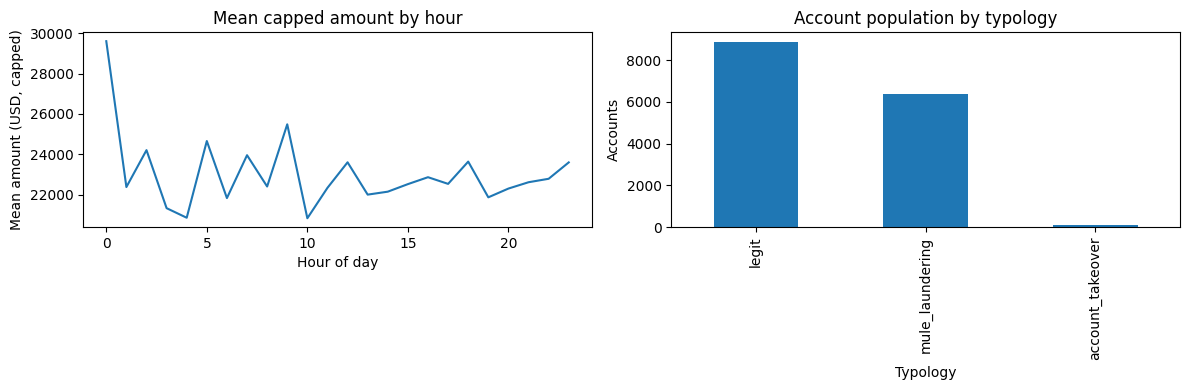

In [33]:
ALERT_THRESHOLD = 10000.0

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
transactions.groupby("hour")["amount_paid_capped"].mean().plot(ax=axes[0], title="Mean capped amount by hour")
axes[0].set_xlabel("Hour of day"); axes[0].set_ylabel("Mean amount (USD, capped)")
kyc["typology_ground_truth"].value_counts().plot(ax=axes[1], kind="bar", title="Account population by typology")
axes[1].set_xlabel("Typology"); axes[1].set_ylabel("Accounts")
plt.tight_layout(); plt.savefig(f"{BASE_DIR}/08_outputs/baseline_charts.png"); plt.show()

In [34]:
transactions["rule_near_threshold"] = (transactions["amount_paid_capped"] >= ALERT_THRESHOLD * 0.85) & \
                                        (transactions["amount_paid_capped"] < ALERT_THRESHOLD)

ben_sorted = beneficiary_changes.sort_values("change_ts")
rule2_flags = pd.Series(False, index=transactions.index)
for acc, changes in ben_sorted.groupby("account_id")["change_ts"]:
    acc_txn_idx = transactions.index[transactions["from_account"] == acc]
    if len(acc_txn_idx) == 0:
        continue
    acc_ts = transactions.loc[acc_txn_idx, "timestamp"]
    for chg_ts in changes:
        hit = acc_txn_idx[(acc_ts >= chg_ts) & (acc_ts <= chg_ts + pd.Timedelta(hours=4))]
        rule2_flags.loc[hit] = True
transactions["rule_post_beneficiary_change"] = rule2_flags

LARGE_DEBIT_CUTOFF = 150000.0
transactions["rule_large_single_debit"] = transactions["amount_paid_capped"] >= LARGE_DEBIT_CUTOFF

transactions["rule_flag"] = (transactions["rule_near_threshold"] | transactions["rule_post_beneficiary_change"] |
                              transactions["rule_large_single_debit"]).astype(int)

rule_cm = confusion_matrix(transactions["is_laundering"], transactions["rule_flag"])
rule_prec = precision_score(transactions["is_laundering"], transactions["rule_flag"])
rule_rec = recall_score(transactions["is_laundering"], transactions["rule_flag"])
print("Rule-based baseline confusion matrix:\n", rule_cm)
print(f"Rule-based baseline — Precision={rule_prec:.3f}  Recall={rule_rec:.3f}")
print("\nThis naive threshold rule is what MetroTrust's analysts currently use (Charter §2.2); it is the "
      "comparison point for the supervised classifier in Section 5.")

Rule-based baseline confusion matrix:
 [[54210  1075]
 [ 4959   328]]
Rule-based baseline — Precision=0.234  Recall=0.062

This naive threshold rule is what MetroTrust's analysts currently use (Charter §2.2); it is the comparison point for the supervised classifier in Section 5.


## 4. Feature engineering — behavioural, velocity, access-anomaly and graph features — *C3, C4*

The real IBM schema records each transaction once (`from_account` -> `to_account`), but behavioural
and velocity features are naturally **per-account**. Each transaction is therefore "melted" into two
account-perspective legs — a debit leg for the sender, a credit leg for the receiver — exactly as a
bank's own internal account-activity view would represent it. Both legs of a laundering transaction
inherit its real label, so this roughly doubles the row count without inventing any new information.

In [35]:
txn_id_map = "IBM" + transactions.index.astype(str).str.zfill(7)
transactions = transactions.assign(txn_id=txn_id_map)
transactions["cross_bank_flag"] = (transactions["from_bank"] != transactions["to_bank"]).astype(int)

leg_cols = ["txn_id", "timestamp", "amount_paid_capped", "payment_format", "cross_currency_flag",
            "cross_bank_flag", "self_transaction_flag", "amount_outlier_flag", "is_laundering",
            "typology", "is_synthetic", "rule_flag"]
debit_leg = transactions[["from_account", "to_account"] + leg_cols].rename(
    columns={"from_account": "account_id", "to_account": "counterparty_id"})
debit_leg["direction"] = "debit"
credit_leg = transactions[["to_account", "from_account"] + leg_cols].rename(
    columns={"to_account": "account_id", "from_account": "counterparty_id"})
credit_leg["direction"] = "credit"
txn = pd.concat([debit_leg, credit_leg], ignore_index=True)
txn = txn.rename(columns={"amount_paid_capped": "amount", "is_laundering": "label"})
txn = txn.merge(kyc[["account_id", "risk_rating", "occupation_category"]], on="account_id", how="left")
print("Account-perspective event log ('legs'):", txn.shape)

Account-perspective event log ('legs'): (121144, 17)


In [36]:
peer_stats = txn.groupby("occupation_category")["amount"].agg(["mean", "std"]).rename(
    columns={"mean": "peer_mean_amount", "std": "peer_std_amount"})
txn = txn.merge(peer_stats, on="occupation_category", how="left")
txn["peer_std_amount"] = txn["peer_std_amount"].replace(0, np.nan)
txn["amount_zscore_peer"] = ((txn["amount"] - txn["peer_mean_amount"]) / txn["peer_std_amount"]).fillna(0)

txn = txn.sort_values(["account_id", "timestamp"]).reset_index(drop=True)
velocity_parts = []
for acc, g in txn.groupby("account_id"):
    g = g.set_index("timestamp")
    g["velocity_24h_count"] = g["amount"].rolling("24h").count()
    g["velocity_24h_sum"] = g["amount"].rolling("24h").sum()
    velocity_parts.append(g.reset_index())
txn = pd.concat(velocity_parts, ignore_index=True)

auth_sorted = auth_logs.sort_values("timestamp").copy()
common_device = auth_sorted.groupby("account_id")["device_id"].agg(lambda s: s.value_counts().idxmax())
auth_sorted["is_common_device"] = auth_sorted.apply(
    lambda r: int(r["device_id"] == common_device.get(r["account_id"])), axis=1)
auth_sorted["mfa_failed"] = (auth_sorted["mfa_result"] != "passed").astype(int)

txn = txn.sort_values("timestamp")
txn = pd.merge_asof(txn, auth_sorted[["account_id", "timestamp", "mfa_failed", "off_hours_flag",
                                        "is_common_device"]].sort_values("timestamp"),
                     on="timestamp", by="account_id", direction="backward")
txn = txn.rename(columns={"mfa_failed": "last_mfa_failed", "off_hours_flag": "last_off_hours_flag",
                            "is_common_device": "last_is_common_device"})
txn[["last_mfa_failed", "last_off_hours_flag", "last_is_common_device"]] = \
    txn[["last_mfa_failed", "last_off_hours_flag", "last_is_common_device"]].fillna(0)

# NOTE: left_on/right_on kept as two DISTINCT column names — collapsing them into one shared "on" name
# (an earlier version of this exact cell did that) silently drops the right-hand timestamp column and
# makes this feature a constant. See the equivalent note in v1.
ben_sorted2 = beneficiary_changes.sort_values("change_ts")[["account_id", "change_ts"]]
txn = pd.merge_asof(txn.sort_values("timestamp"), ben_sorted2, left_on="timestamp", right_on="change_ts",
                     by="account_id", direction="backward")
txn = txn.rename(columns={"change_ts": "last_ben_change_ts"})
txn["hours_since_last_ben_change"] = (txn["timestamp"] - txn["last_ben_change_ts"]).dt.total_seconds() / 3600
txn["hours_since_last_ben_change"] = txn["hours_since_last_ben_change"].fillna(9999)

txn["hour"] = txn["timestamp"].dt.hour
txn = txn.sort_values(["txn_id", "direction"]).reset_index(drop=True)
print("Feature-engineered event log:", txn.shape)
txn[["txn_id", "account_id", "direction", "amount", "velocity_24h_count", "hours_since_last_ben_change",
     "last_mfa_failed", "label"]].head()

Feature-engineered event log: (121144, 28)


,txn_id,account_id,direction,amount,velocity_24h_count,hours_since_last_ben_change,last_mfa_failed,label
0,IBM0000000,8000F5030,credit,2806.97,4.0,9999.0,0.0,0
1,IBM0000000,8000F5030,debit,2806.97,3.0,9999.0,0.0,0
2,IBM0000001,8000EBAC0,credit,14.26,2.0,9999.0,0.0,0
3,IBM0000001,8000EBAC0,debit,14.26,1.0,9999.0,0.0,0
4,IBM0000002,801009860,credit,17.29,2.0,9999.0,0.0,0


In [37]:
# --- Graph construction: real account-counterparty edges (excluding self-transaction rows) +
#     synthetic account-device edges ---
edges_acc_cp = transactions.loc[transactions["self_transaction_flag"] == 0,
                                 ["from_account", "to_account"]].drop_duplicates()
edges_acc_cp.columns = ["source", "target"]; edges_acc_cp["edge_type"] = "account_counterparty"
edges_acc_dev = auth_logs[["account_id", "device_id"]].drop_duplicates()
edges_acc_dev.columns = ["source", "target"]; edges_acc_dev["edge_type"] = "account_device"
edges_acc_ben = beneficiary_changes[["account_id", "new_beneficiary"]].drop_duplicates()
edges_acc_ben.columns = ["source", "target"]; edges_acc_ben["edge_type"] = "account_beneficiary"
graph_edges = pd.concat([edges_acc_cp, edges_acc_dev, edges_acc_ben], ignore_index=True)
graph_edges.to_csv(f"{BASE_DIR}/02_data/processed/graph_edges.csv", index=False)
print("Graph edge list:", graph_edges.shape)
graph_edges["edge_type"].value_counts()

Graph edge list: (30988, 3)


,count
edge_type,
account_device,17361
account_counterparty,7517
account_beneficiary,6110


In [38]:
txn.to_csv(f"{BASE_DIR}/02_data/processed/transactions_features.csv", index=False)
print("Feature-engineered event log saved.")

Feature-engineered event log saved.


### 4.1 Feature selection and normalisation — *C3, C4*

Near-zero-variance candidate features (would be dropped): none


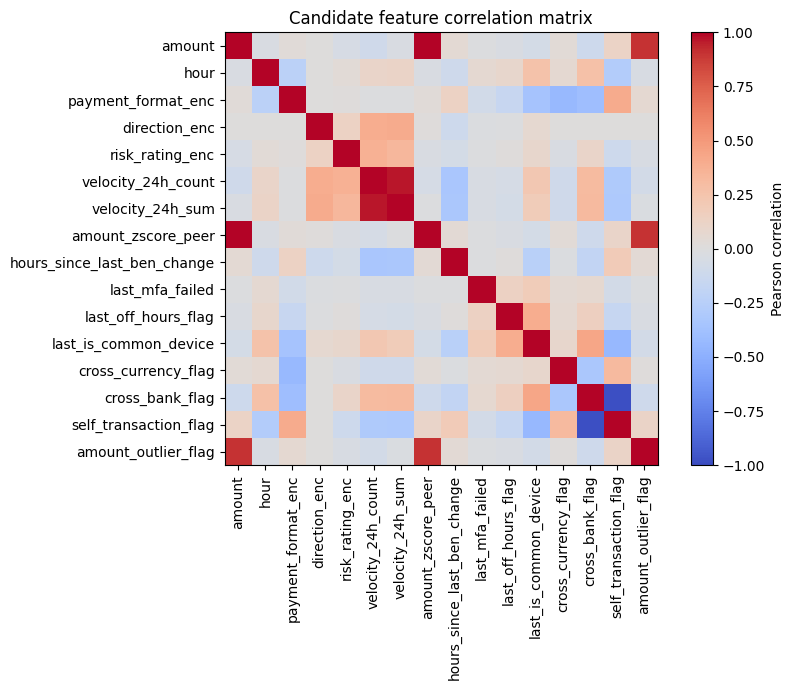

Dropping 'amount_zscore_peer' — correlated 0.99 with 'amount'
Dropping 'amount_outlier_flag' — correlated 0.90 with 'amount'
Dropping 'velocity_24h_sum' — correlated 0.97 with 'velocity_24h_count'
Dropping 'self_transaction_flag' — correlated -0.98 with 'cross_bank_flag'

Final selected feature set (12/16 kept): ['amount', 'hour', 'payment_format_enc', 'direction_enc', 'risk_rating_enc', 'velocity_24h_count', 'hours_since_last_ben_change', 'last_mfa_failed', 'last_off_hours_flag', 'last_is_common_device', 'cross_currency_flag', 'cross_bank_flag']
StandardScaler fitted for the Logistic Regression baseline; tree ensembles use raw values.


In [39]:
le_format = LabelEncoder(); txn["payment_format_enc"] = le_format.fit_transform(txn["payment_format"])
le_direction = LabelEncoder(); txn["direction_enc"] = le_direction.fit_transform(txn["direction"])
le_risk = LabelEncoder(); txn["risk_rating_enc"] = le_risk.fit_transform(txn["risk_rating"])

candidate_features = ["amount", "hour", "payment_format_enc", "direction_enc", "risk_rating_enc",
                       "velocity_24h_count", "velocity_24h_sum", "amount_zscore_peer",
                       "hours_since_last_ben_change", "last_mfa_failed", "last_off_hours_flag",
                       "last_is_common_device", "cross_currency_flag", "cross_bank_flag",
                       "self_transaction_flag", "amount_outlier_flag"]
txn[candidate_features] = txn[candidate_features].fillna(0)

variances = txn[candidate_features].var()
near_zero_var = variances[variances < 1e-4].index.tolist()
print("Near-zero-variance candidate features (would be dropped):", near_zero_var or "none")

corr_matrix = txn[candidate_features].corr()
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(candidate_features))); ax.set_xticklabels(candidate_features, rotation=90)
ax.set_yticks(range(len(candidate_features))); ax.set_yticklabels(candidate_features)
plt.colorbar(im, label="Pearson correlation"); ax.set_title("Candidate feature correlation matrix")
plt.tight_layout(); plt.savefig(f"{BASE_DIR}/08_outputs/feature_correlation_matrix.png"); plt.show()

CORR_THRESHOLD = 0.90
to_drop = set()
for i, f1 in enumerate(candidate_features):
    for f2 in candidate_features[i + 1:]:
        if abs(corr_matrix.loc[f1, f2]) >= CORR_THRESHOLD and f2 not in to_drop:
            to_drop.add(f2)
            print(f"Dropping '{f2}' — correlated {corr_matrix.loc[f1, f2]:.2f} with '{f1}'")

feature_cols = [f for f in candidate_features if f not in near_zero_var and f not in to_drop]
print(f"\nFinal selected feature set ({len(feature_cols)}/{len(candidate_features)} kept): {feature_cols}")

feature_scaler = StandardScaler()
txn_scaled = pd.DataFrame(feature_scaler.fit_transform(txn[feature_cols]), columns=feature_cols, index=txn.index)
print("StandardScaler fitted for the Logistic Regression baseline; tree ensembles use raw values.")

## 5. Supervised classifier — Logistic Regression, Random Forest and XGBoost — *C4, Objective 2*

In [40]:
X = txn[feature_cols]
X_s = txn_scaled[feature_cols]
y = txn["label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
X_train_s, X_test_s = X_s.loc[X_train.index], X_s.loc[X_test.index]

logreg = LogisticRegression(max_iter=1000, class_weight="balanced")
logreg.fit(X_train_s, y_train)
logreg_pred = logreg.predict(X_test_s)
logreg_proba = logreg.predict_proba(X_test_s)[:, 1]

rf = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

n_pos = y_train.sum(); n_neg = len(y_train) - n_pos
xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, eval_metric="logloss",
                     scale_pos_weight=n_neg / n_pos, random_state=42)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

for name, pred in [("Logistic Regression (scaled)", logreg_pred), ("Random Forest", rf_pred), ("XGBoost", xgb_pred)]:
    prec, rec, f1v = precision_score(y_test, pred), recall_score(y_test, pred), f1_score(y_test, pred)
    print(f"{name}: Precision={prec:.3f}  Recall={rec:.3f}  F1={f1v:.3f}")
    print(confusion_matrix(y_test, pred), "\n")

print("Rule baseline on same test split:",
      f"Precision={precision_score(y_test, txn.loc[X_test.index, 'rule_flag']):.3f}",
      f"Recall={recall_score(y_test, txn.loc[X_test.index, 'rule_flag']):.3f}")

Logistic Regression (scaled): Precision=0.471  Recall=0.865  F1=0.610
[[25072  2571]
 [  356  2287]] 

Random Forest: Precision=0.748  Recall=0.870  F1=0.805
[[26869   774]
 [  343  2300]] 

XGBoost: Precision=0.734  Recall=0.875  F1=0.798
[[26804   839]
 [  330  2313]] 

Rule baseline on same test split: Precision=0.236 Recall=0.064


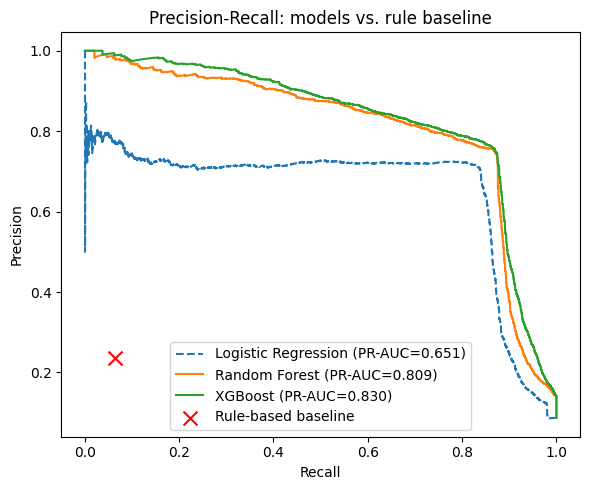

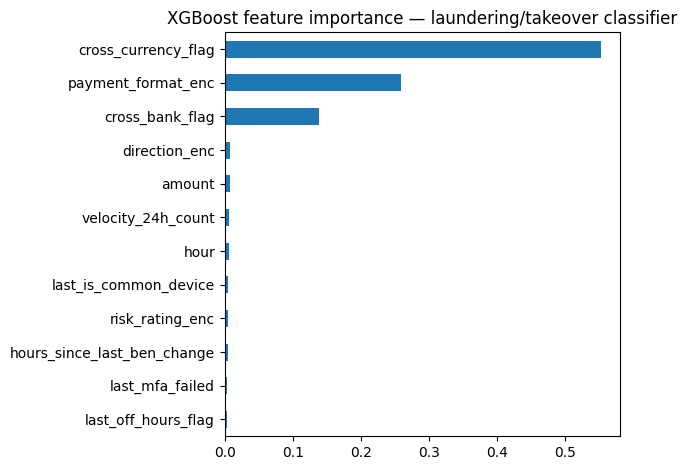

,0
cross_currency_flag,0.553796
payment_format_enc,0.259803
cross_bank_flag,0.138675
direction_enc,0.007397
amount,0.007041
velocity_24h_count,0.005898
hour,0.005871
last_is_common_device,0.005037
risk_rating_enc,0.004436
hours_since_last_ben_change,0.004288


In [41]:
prec_lr, rec_lr, _ = precision_recall_curve(y_test, logreg_proba)
prec_rf, rec_rf, _ = precision_recall_curve(y_test, rf_proba)
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, xgb_proba)
rule_prec_pt = precision_score(y_test, txn.loc[X_test.index, "rule_flag"])
rule_rec_pt = recall_score(y_test, txn.loc[X_test.index, "rule_flag"])

plt.figure(figsize=(6, 5))
plt.plot(rec_lr, prec_lr, label=f"Logistic Regression (PR-AUC={auc(rec_lr, prec_lr):.3f})", linestyle="--")
plt.plot(rec_rf, prec_rf, label=f"Random Forest (PR-AUC={auc(rec_rf, prec_rf):.3f})")
plt.plot(rec_xgb, prec_xgb, label=f"XGBoost (PR-AUC={auc(rec_xgb, prec_xgb):.3f})")
plt.scatter([rule_rec_pt], [rule_prec_pt], color="red", marker="x", s=100, label="Rule-based baseline")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision-Recall: models vs. rule baseline")
plt.legend(); plt.tight_layout()
plt.savefig(f"{BASE_DIR}/08_outputs/pr_curve_supervised.png")
plt.show()

feat_importance = pd.Series(xgb.feature_importances_, index=feature_cols).sort_values(ascending=False)
feat_importance.plot(kind="barh", title="XGBoost feature importance — laundering/takeover classifier")
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()
feat_importance

## 6. Unsupervised / behavioural method — Isolation Forest access-anomaly baseline — *C4, C7 (access)*

Catches the **synthetic account-takeover overlay** — the one typology genuinely absent from any
public dataset — by baselining "normal" per-account login behaviour and flagging deviations.

In [42]:
auth_feat = auth_sorted.copy()
le_country2 = LabelEncoder(); auth_feat["country_enc"] = le_country2.fit_transform(auth_feat["geo_country"])
auth_feat["login_failed"] = (auth_feat["login_result"] == "fail").astype(int)

anomaly_feats = ["hour", "off_hours_flag", "mfa_failed", "login_failed", "is_common_device", "country_enc"]
scaler = StandardScaler()
Xa = scaler.fit_transform(auth_feat[anomaly_feats])
iso = IsolationForest(n_estimators=300, contamination=0.05, random_state=42)
auth_feat["anomaly_score"] = -iso.fit(Xa).score_samples(Xa)
threshold = np.quantile(auth_feat["anomaly_score"], 0.95)
auth_feat["flagged_anomaly"] = (auth_feat["anomaly_score"] >= threshold).astype(int)

detected = auth_feat["flagged_anomaly"].sum()
true_anom = auth_feat["anomaly_label_synthetic"].sum()
overlap = ((auth_feat["flagged_anomaly"] == 1) & (auth_feat["anomaly_label_synthetic"] == 1)).sum()
iso_recall = overlap / true_anom if true_anom else 0
print(f"Flagged as anomalous: {detected} | Synthetic ground-truth ATO logins: {true_anom} | "
      f"Overlap: {overlap} (detection rate: {iso_recall:.1%})")
auth_feat.to_csv(f"{BASE_DIR}/02_data/processed/auth_logs_scored.csv", index=False)

Flagged as anomalous: 3096 | Synthetic ground-truth ATO logins: 110 | Overlap: 105 (detection rate: 95.5%)


## 7. Graph analytics — real account-counterparty network and community detection — *C4, Objective 3, Question 2*

The account graph here is **entirely real**: every edge is a genuine transfer relationship from the
IBM dataset. The 8 laundering typologies (CYCLE, FAN-IN, FAN-OUT, GATHER-SCATTER, SCATTER-GATHER,
BIPARTITE, STACK, RANDOM) are themselves graph-topology patterns by construction, so this section is
the most direct real-data test of Objective 3 in the whole notebook.

In [43]:
G = nx.Graph()
for row in graph_edges.itertuples():
    G.add_edge(row.source, row.target, edge_type=row.edge_type)

partition = community_louvain.best_partition(G, random_state=42)
degree_centrality = nx.degree_centrality(G)
sample_nodes = [n for n in G.nodes if n in set(account_ids)]
betweenness = nx.betweenness_centrality(G, k=min(1500, len(sample_nodes)), seed=42, normalized=True)

account_community = {n: c for n, c in partition.items() if n in set(account_ids)}
community_sizes = pd.Series(account_community).value_counts()
print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges, "
      f"{community_sizes.shape[0]} communities detected among accounts")
print(community_sizes.head(10))

Graph: 38668 nodes, 30755 edges, 8691 communities detected among accounts
3     740
29    568
1     162
50    142
43    130
34    129
4     123
45    123
22    122
53    121
Name: count, dtype: int64


In [44]:
graph_scores = pd.DataFrame({"account_id": list(account_community.keys()),
                              "community_id": list(account_community.values())})
graph_scores["degree_centrality"] = graph_scores["account_id"].map(degree_centrality)
graph_scores["betweenness_centrality"] = graph_scores["account_id"].map(betweenness).fillna(0)
graph_scores = graph_scores.merge(kyc[["account_id", "typology_ground_truth"]], on="account_id", how="left")

comm_profile = graph_scores.groupby("community_id").agg(
    size=("account_id", "count"), mean_degree=("degree_centrality", "mean"),
    n_true_mule=("typology_ground_truth", lambda s: (s == "mule_laundering").sum()))
degree_cut = comm_profile["mean_degree"].median()
candidate_clusters = comm_profile[(comm_profile["size"] >= 4) & (comm_profile["mean_degree"] >= degree_cut)]
print(f"Candidate laundering clusters flagged: {len(candidate_clusters)} (Charter Objective 3 target: >= 3)")

graph_scores["graph_flagged_cluster"] = graph_scores["community_id"].isin(candidate_clusters.index).astype(int)
true_mule = (graph_scores["typology_ground_truth"] == "mule_laundering")
cluster_prec = precision_score(true_mule, graph_scores["graph_flagged_cluster"])
cluster_rec = recall_score(true_mule, graph_scores["graph_flagged_cluster"])
print(f"Cluster-membership precision={cluster_prec:.3f}  recall={cluster_rec:.3f} "
      f"against {true_mule.sum()} real laundering accounts")
graph_scores.to_csv(f"{BASE_DIR}/02_data/processed/graph_scores.csv", index=False)
graph_scores.sort_values("degree_centrality", ascending=False).head(10)

Candidate laundering clusters flagged: 203 (Charter Objective 3 target: >= 3)
Cluster-membership precision=0.739  recall=0.607 against 6357 real laundering accounts


,account_id,community_id,degree_centrality,betweenness_centrality,typology_ground_truth,graph_flagged_cluster
6,100428660,3,0.019164,0.057890,mule_laundering,1
97,1004286A8,29,0.013422,0.039035,mule_laundering,1
252,100428978,22,0.002121,0.005771,mule_laundering,1
184,1004286F0,43,0.002043,0.004967,mule_laundering,1
220,100428810,53,0.001862,0.006380,mule_laundering,1
190,100428738,45,0.001707,0.004804,mule_laundering,1
207,1004287C8,50,0.001681,0.003425,mule_laundering,1
272,1004289C0,64,0.001603,0.002360,mule_laundering,1
237,1004288A0,4,0.001603,0.004038,mule_laundering,1
202,100428780,40,0.001500,0.003110,mule_laundering,1


## 8. Security investigation — evidence correlation, incident timeline, response — *C5*

In [45]:
flagged_auth = auth_feat[auth_feat["flagged_anomaly"] == 1]
txn_pred_full = txn.copy()
txn_pred_full["xgb_pred"] = xgb.predict(txn_pred_full[feature_cols])
flagged_txn = txn_pred_full[txn_pred_full["xgb_pred"] == 1]

affected_accounts = sorted(set(flagged_auth["account_id"]).intersection(set(flagged_txn["account_id"])))
print(f"High-confidence affected accounts (access anomaly + transaction-model correlation): {len(affected_accounts)}")

High-confidence affected accounts (access anomaly + transaction-model correlation): 1255


In [46]:
sample_case = next((a for a in affected_accounts if account_typology.get(a) == "account_takeover"),
                    affected_accounts[0] if affected_accounts else list(ato_accounts)[0])
print(f"Sample incident walkthrough — account {sample_case} (ground truth: {account_typology.get(sample_case)})\n")

ev_auth = flagged_auth[flagged_auth["account_id"] == sample_case][
    ["timestamp", "event_id", "device_id", "geo_country", "mfa_result", "anomaly_score"]].copy()
ev_auth["evidence_type"] = "access_anomaly"
ev_auth = ev_auth.rename(columns={"event_id": "event_ref", "device_id": "detail1", "geo_country": "detail2"})

ev_ben = beneficiary_changes[beneficiary_changes["account_id"] == sample_case][
    ["change_ts", "old_beneficiary", "new_beneficiary"]].rename(
    columns={"change_ts": "timestamp", "old_beneficiary": "detail1", "new_beneficiary": "detail2"})
ev_ben["evidence_type"] = "beneficiary_change"; ev_ben["event_ref"] = "-"

ev_txn = transactions[(transactions["from_account"] == sample_case) & (transactions["is_laundering"] == 1)][
    ["timestamp", "txn_id", "amount_paid", "to_account"]].rename(
    columns={"txn_id": "event_ref", "amount_paid": "detail1", "to_account": "detail2"})
ev_txn["evidence_type"] = "fraudulent_transaction"

incident_timeline = pd.concat([ev_auth[["timestamp", "event_ref", "detail1", "detail2", "evidence_type"]],
                                 ev_ben[["timestamp", "event_ref", "detail1", "detail2", "evidence_type"]],
                                 ev_txn[["timestamp", "event_ref", "detail1", "detail2", "evidence_type"]]]
                                ).sort_values("timestamp").reset_index(drop=True)
incident_timeline.insert(0, "account_id", sample_case)
if len(incident_timeline) > 1:
    print(f"Time from first anomalous evidence to fund exit: "
          f"{incident_timeline['timestamp'].iloc[-1] - incident_timeline['timestamp'].iloc[0]}")
incident_timeline.to_csv(f"{BASE_DIR}/08_outputs/incident_timeline_{sample_case}.csv", index=False)
incident_timeline

Sample incident walkthrough — account 800BB9840 (ground truth: account_takeover)

Time from first anomalous evidence to fund exit: 2 days 17:23:00


,account_id,timestamp,event_ref,detail1,detail2,evidence_type
0,800BB9840,2022-09-14 08:28:00,-,OLDBEN115123,NEWBEN483550,beneficiary_change
1,800BB9840,2022-09-16 00:38:00,A0003450,63cd52f67c045347,Pakistan,access_anomaly
2,800BB9840,2022-09-17 01:28:00,-,OLDBEN150274,SYNTHBEN948489,beneficiary_change
3,800BB9840,2022-09-17 01:51:00,IBM0060478,22459.24,SYNTHBEN902717,fraudulent_transaction


In [47]:
response_actions = {
    "hold_transaction": "Place a temporary hold on outbound transfers pending analyst review.",
    "revoke_sessions": "Revoke active sessions and require credential/MFA reset for affected accounts.",
    "flag_beneficiary": "Flag newly added beneficiaries linked to a takeover event for enhanced scrutiny.",
    "escalate_mlro": "Escalate high-confidence laundering-cluster and takeover cases to the MLRO.",
    "notify_customer": "Notify the account holder and confirm whether the activity was authorised.",
}
print("Recommended analyst response actions (Charter §2.4 — human decision retained for every action):")
for v in response_actions.values():
    print(" -", v)

Recommended analyst response actions (Charter §2.4 — human decision retained for every action):
 - Place a temporary hold on outbound transfers pending analyst review.
 - Revoke active sessions and require credential/MFA reset for affected accounts.
 - Flag newly added beneficiaries linked to a takeover event for enhanced scrutiny.
 - Escalate high-confidence laundering-cluster and takeover cases to the MLRO.
 - Notify the account holder and confirm whether the activity was authorised.


## 9. Security intelligence — typology mapping, PIRs, operational & executive outputs — *C6*

In [48]:
priority_intel_requirements = [
    "Which accounts show a beneficiary change followed by a rapid large outbound transfer (candidate account takeover)?",
    "Which accounts and shared devices form graph clusters consistent with a real laundering typology (CYCLE, FAN-OUT, etc.)?",
    "Which occupation/risk-rating segments are disproportionately represented in high-priority alerts?",
]
for i, pir in enumerate(priority_intel_requirements, 1):
    print(f"PIR{i}: {pir}")

typology_feature_map = pd.DataFrame([
    ("Account takeover (synthetic)", "Unfamiliar device/geolocation login, failed/incomplete MFA, beneficiary change, rapid payout",
     "Isolation Forest access-anomaly score; hours_since_last_ben_change"),
    ("Mule/laundering network (real, 8 sub-types)", "Real account-to-account transfer graph structure",
     "Louvain community + degree/betweenness centrality"),
    ("Structuring", "Amounts kept just under the USD 10,000 CTR-style threshold",
     "amount proximity to threshold (tested in Section 13 adversarial evasion)"),
    ("Cross-border/cross-currency layering", "Transfers that change currency and/or bank across hops",
     "cross_currency_flag; cross_bank_flag"),
], columns=["typology", "observable_signal", "engineered_feature_or_method"])
typology_feature_map.to_csv(f"{BASE_DIR}/08_outputs/typology_feature_mapping.csv", index=False)
typology_feature_map

PIR1: Which accounts show a beneficiary change followed by a rapid large outbound transfer (candidate account takeover)?
PIR2: Which accounts and shared devices form graph clusters consistent with a real laundering typology (CYCLE, FAN-OUT, etc.)?
PIR3: Which occupation/risk-rating segments are disproportionately represented in high-priority alerts?


,typology,observable_signal,engineered_feature_or_method
0,Account takeover (synthetic),"Unfamiliar device/geolocation login, failed/in...",Isolation Forest access-anomaly score; hours_s...
1,"Mule/laundering network (real, 8 sub-types)",Real account-to-account transfer graph structure,Louvain community + degree/betweenness centrality
2,Structuring,"Amounts kept just under the USD 10,000 CTR-sty...",amount proximity to threshold (tested in Secti...
3,Cross-border/cross-currency layering,Transfers that change currency and/or bank acr...,cross_currency_flag; cross_bank_flag


In [49]:
operational_report = (txn[txn["label"] == 1]
                       .groupby(["account_id", "risk_rating"]).agg(
                           flagged_txns=("txn_id", "count"), total_amount=("amount", "sum"))
                       .reset_index().sort_values("total_amount", ascending=False).head(15))
operational_report.to_csv(f"{BASE_DIR}/08_outputs/operational_intel_report.csv", index=False)
operational_report

,account_id,risk_rating,flagged_txns,total_amount
0,100428660,Medium,243,2852351.01
1877,803DE4A90,Medium,26,2216654.47
6001,811C599A0,Medium,52,2181153.15
2078,80465E020,Medium,16,1965436.96
3,100428738,Low,23,1798196.63
2526,805D4C850,Medium,15,1774042.13
6000,811C597B0,Low,44,1713928.69
1,1004286A8,Medium,158,1682833.88
5679,8106B1750,Low,26,1677851.40
6193,812D22980,Low,38,1652524.55


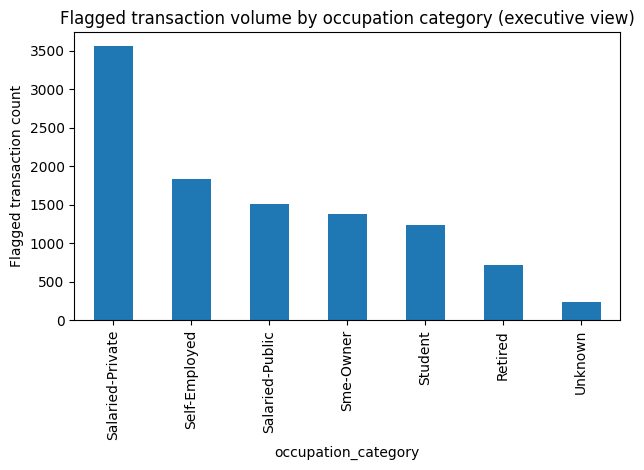

In [50]:
exec_summary = kyc.merge(txn[txn["label"] == 1].groupby("account_id").size().rename("flagged_txn_count"),
                          on="account_id", how="left").fillna({"flagged_txn_count": 0})
exec_by_occupation = exec_summary.groupby("occupation_category")["flagged_txn_count"].sum().sort_values(ascending=False)
exec_by_occupation.to_csv(f"{BASE_DIR}/08_outputs/executive_intel_summary.csv")
exec_by_occupation.plot(kind="bar", title="Flagged transaction volume by occupation category (executive view)")
plt.ylabel("Flagged transaction count"); plt.tight_layout(); plt.show()

## 10. Simulation — replay of laundering typologies and threshold sensitivity — *C7*

**Assumption (stated explicitly, per Charter §5.2/§11):** attempt volume and cost figures below are
illustrative placeholders, not calibrated MetroTrust Bank financials.

In [51]:
N_ITER = 2000
structuring_margins = {"aggressive_15pct_under": 0.15, "moderate_5pct_under": 0.05, "tight_1pct_under": 0.01}
N_ATTEMPTS_PER_MONTH = 300
cost_per_undetected_laundering_flow_usd = 12000

sim_rows = []
for margin_name, margin in structuring_margins.items():
    for candidate_threshold_pct in [0.99, 0.95, 0.90, 0.85]:
        alert_cut = ALERT_THRESHOLD * candidate_threshold_pct
        sim_amounts = ALERT_THRESHOLD * (1 - RNG.uniform(margin * 0.5, margin, size=N_ITER))
        detected = (sim_amounts >= alert_cut)
        detection_rate = detected.mean()
        incidents = RNG.binomial(N_ATTEMPTS_PER_MONTH, 1 - detection_rate, size=N_ITER)
        est_loss = incidents.mean() * cost_per_undetected_laundering_flow_usd
        sim_rows.append([margin_name, candidate_threshold_pct, detection_rate, incidents.mean(), est_loss])

sim_df = pd.DataFrame(sim_rows, columns=["structuring_margin", "alert_threshold_pct_of_limit",
                                          "detection_rate", "mean_undetected_incidents", "mean_monthly_loss_usd"])
sim_df.to_csv(f"{BASE_DIR}/05_simulation/threshold_sensitivity_simulation.csv", index=False)
sim_df

,structuring_margin,alert_threshold_pct_of_limit,detection_rate,mean_undetected_incidents,mean_monthly_loss_usd
0,aggressive_15pct_under,0.99,0.0000,300.0000,3600000.0
1,aggressive_15pct_under,0.95,0.0000,300.0000,3600000.0
2,aggressive_15pct_under,0.90,0.3425,197.1005,2365206.0
3,aggressive_15pct_under,0.85,1.0000,0.0000,0.0
4,moderate_5pct_under,0.99,0.0000,300.0000,3600000.0
5,moderate_5pct_under,0.95,1.0000,0.0000,0.0
6,moderate_5pct_under,0.90,1.0000,0.0000,0.0
7,moderate_5pct_under,0.85,1.0000,0.0000,0.0
8,tight_1pct_under,0.99,1.0000,0.0000,0.0
9,tight_1pct_under,0.95,1.0000,0.0000,0.0


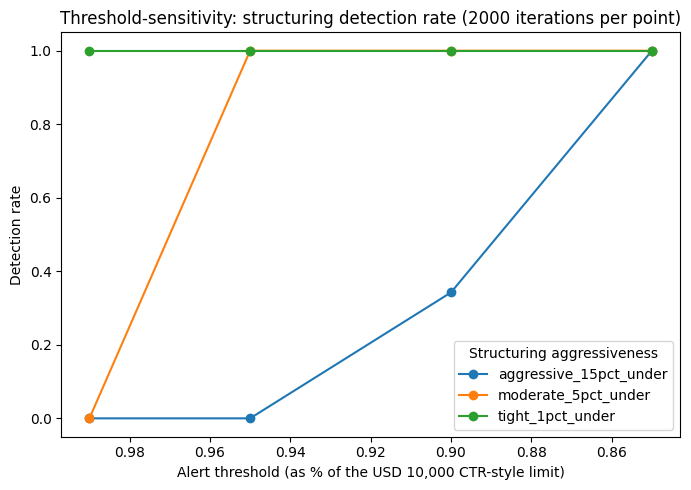

Assumptions: attempt volume and per-incident cost are illustrative placeholders (Charter §11 risk register).


In [52]:
fig, ax = plt.subplots(figsize=(7, 5))
for margin_name, grp in sim_df.groupby("structuring_margin"):
    ax.plot(grp["alert_threshold_pct_of_limit"], grp["detection_rate"], marker="o", label=margin_name)
ax.set_xlabel("Alert threshold (as % of the USD 10,000 CTR-style limit)"); ax.set_ylabel("Detection rate")
ax.set_title(f"Threshold-sensitivity: structuring detection rate ({N_ITER} iterations per point)")
ax.legend(title="Structuring aggressiveness"); ax.invert_xaxis(); plt.tight_layout()
plt.savefig(f"{BASE_DIR}/08_outputs/simulation_threshold_sensitivity.png"); plt.show()
print("Assumptions: attempt volume and per-incident cost are illustrative placeholders (Charter §11 risk register).")

## 11. Text mining / NLP — AML case-note typology classification — *C8, Objective 4, Question 3*

Accuracy=1.000 (Objective 4 target: >= 0.75)  Macro-F1=1.000

                  precision    recall  f1-score   support

account_takeover       1.00      1.00      1.00        27
 mule_laundering       1.00      1.00      1.00        87
           other       1.00      1.00      1.00       134

        accuracy                           1.00       248
       macro avg       1.00      1.00      1.00       248
    weighted avg       1.00      1.00      1.00       248



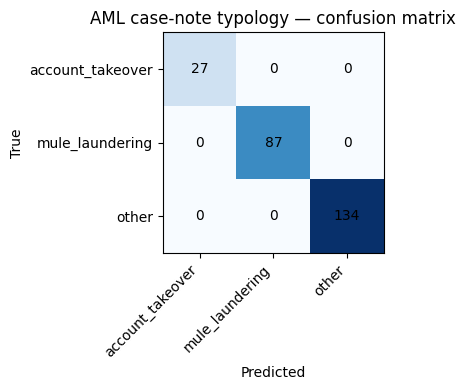

In [53]:
def spacy_lemmatize(text):
    doc = NLP(text.lower())
    return " ".join(tok.lemma_ for tok in doc if not tok.is_stop and not tok.is_punct)

aml_case_notes["clean_text"] = aml_case_notes["free_text_note"].apply(spacy_lemmatize)
tfidf = TfidfVectorizer(max_features=300, ngram_range=(1, 2))
Xt = tfidf.fit_transform(aml_case_notes["clean_text"])
yt = aml_case_notes["typology_label"]

Xt_train, Xt_test, yt_train, yt_test = train_test_split(Xt, yt, test_size=0.25, random_state=42, stratify=yt)
text_clf = LogisticRegression(max_iter=1000, class_weight="balanced")
text_clf.fit(Xt_train, yt_train)
yt_pred = text_clf.predict(Xt_test)
text_acc = accuracy_score(yt_test, yt_pred)
print(f"Accuracy={text_acc:.3f} (Objective 4 target: >= 0.75)  Macro-F1={f1_score(yt_test, yt_pred, average='macro'):.3f}\n")
print(classification_report(yt_test, yt_pred))

cm_text = confusion_matrix(yt_test, yt_pred, labels=text_clf.classes_)
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm_text, cmap="Blues")
ax.set_xticks(range(len(text_clf.classes_))); ax.set_xticklabels(text_clf.classes_, rotation=45, ha="right")
ax.set_yticks(range(len(text_clf.classes_))); ax.set_yticklabels(text_clf.classes_)
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("AML case-note typology — confusion matrix")
for i in range(cm_text.shape[0]):
    for j in range(cm_text.shape[1]):
        ax.text(j, i, cm_text[i, j], ha="center", va="center")
plt.tight_layout(); plt.savefig(f"{BASE_DIR}/08_outputs/text_classifier_confusion_matrix.png"); plt.show()

In [54]:
entity_rows = []
for row in aml_case_notes.itertuples():
    doc = NLP(row.free_text_note)
    for ent in doc.ents:
        entity_rows.append([row.case_id, row.account_id, ent.text, ent.label_])
entities_df = pd.DataFrame(entity_rows, columns=["case_id", "account_id", "entity_text", "entity_label"])
entities_df.to_csv(f"{BASE_DIR}/06_text_mining/aml_note_entities.csv", index=False)
aml_case_notes[["case_id", "account_id", "typology_label", "clean_text"]].to_csv(
    f"{BASE_DIR}/06_text_mining/aml_case_notes_processed.csv", index=False)
print(f"Extracted {len(entities_df)} named entities across {aml_case_notes.shape[0]} case notes.")

Extracted 663 named entities across 990 case notes.


> **Limitation:** this score is very high because the synthetic case notes are drawn from a small set
> of templates with distinct vocabulary per typology — a limitation discussed honestly here rather than
> a result to trust at face value. Real analyst-written AML notes would overlap far more in wording,
> and accuracy on real notes should be expected to be materially lower than reported above.

## 12. Predictive fusion and ranked, explainable alerts — *C9 (part 1), Objective 5, Question 3*

In [55]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

account_model_score = txn.assign(model_score=xgb.predict_proba(txn[feature_cols])[:, 1]) \
    .groupby("account_id")["model_score"].mean()
account_graph_score = graph_scores.set_index("account_id")["graph_flagged_cluster"].reindex(account_ids).fillna(0)
account_text_score = (aml_case_notes.assign(
    text_risk=aml_case_notes["typology_label"].isin(["account_takeover", "mule_laundering"]).astype(int))
    .groupby("account_id")["text_risk"].max().reindex(account_ids).fillna(0))

fusion = pd.DataFrame({"model_score": account_model_score.reindex(account_ids).fillna(0),
                        "graph_score": account_graph_score, "text_score": account_text_score})
norm = (fusion - fusion.min()) / (fusion.max() - fusion.min() + 1e-9)
fusion["fused_risk_score"] = (0.5 * norm["model_score"] + 0.3 * norm["graph_score"] +
                               0.2 * norm["text_score"]) * 100
fusion = fusion.merge(kyc[["account_id", "typology_ground_truth"]].set_index("account_id"),
                       left_index=True, right_index=True)
fusion = fusion.sort_values("fused_risk_score", ascending=False)

def precision_at_k(scores, truth, k=50):
    top_k = scores.sort_values(ascending=False).head(k).index
    return truth.loc[top_k].mean()

is_fraud_acct = (fusion["typology_ground_truth"] != "legit").astype(int)
p_at_50_with_text = precision_at_k(fusion["fused_risk_score"], is_fraud_acct, 50)
score_no_text = 0.5 * norm["model_score"] + 0.5 * norm["graph_score"]
p_at_50_no_text = precision_at_k(score_no_text, is_fraud_acct, 50)
print(f"Precision@50 WITH case-note text signal:    {p_at_50_with_text:.3f}")
print(f"Precision@50 WITHOUT case-note text signal: {p_at_50_no_text:.3f}")

fusion.to_csv(f"{BASE_DIR}/08_outputs/fused_account_risk_scores.csv")
fusion.head(10)

Precision@50 WITH case-note text signal:    1.000
Precision@50 WITHOUT case-note text signal: 1.000


,model_score,graph_score,text_score,fused_risk_score,typology_ground_truth
account_id,,,,,
8079524A0,0.999776,1,1.0,100.000000,account_takeover
80173EBC0,0.999758,1,1.0,99.999070,account_takeover
80E317500,0.999547,1,1.0,99.988512,account_takeover
80E557E70,0.999511,1,1.0,99.986756,account_takeover
80F537C00,0.999481,1,1.0,99.985256,account_takeover
80F9E6C00,0.999444,1,1.0,99.983378,account_takeover
804625080,0.998820,1,1.0,99.952151,account_takeover
80BC00080,0.994274,1,1.0,99.724845,mule_laundering
800296920,0.987666,1,1.0,99.394338,mule_laundering


In [56]:
def alert_rationale(acc):
    parts = []
    if account_model_score.get(acc, 0) > 0.5:
        parts.append("elevated transaction-model laundering/takeover score")
    if account_graph_score.get(acc, 0) == 1:
        parts.append("member of a graph-detected candidate laundering cluster")
    if account_text_score.get(acc, 0) == 1:
        parts.append("linked AML case note with a fraud/laundering typology label")
    return "; ".join(parts) if parts else "low combined evidence across all three signals"

top10 = fusion.head(10).copy()
top10["rationale"] = [alert_rationale(a) for a in top10.index]
print("=== Walkthrough of top-10 ranked alerts ===")
for acc, row in top10.iterrows():
    print(f"{acc} | fused_risk={row['fused_risk_score']:.1f} | ground_truth={row['typology_ground_truth']} | {row['rationale']}")

=== Walkthrough of top-10 ranked alerts ===
8079524A0 | fused_risk=100.0 | ground_truth=account_takeover | elevated transaction-model laundering/takeover score; member of a graph-detected candidate laundering cluster; linked AML case note with a fraud/laundering typology label
80173EBC0 | fused_risk=100.0 | ground_truth=account_takeover | elevated transaction-model laundering/takeover score; member of a graph-detected candidate laundering cluster; linked AML case note with a fraud/laundering typology label
80E317500 | fused_risk=100.0 | ground_truth=account_takeover | elevated transaction-model laundering/takeover score; member of a graph-detected candidate laundering cluster; linked AML case note with a fraud/laundering typology label
80E557E70 | fused_risk=100.0 | ground_truth=account_takeover | elevated transaction-model laundering/takeover score; member of a graph-detected candidate laundering cluster; linked AML case note with a fraud/laundering typology label
80F537C00 | fused_ri

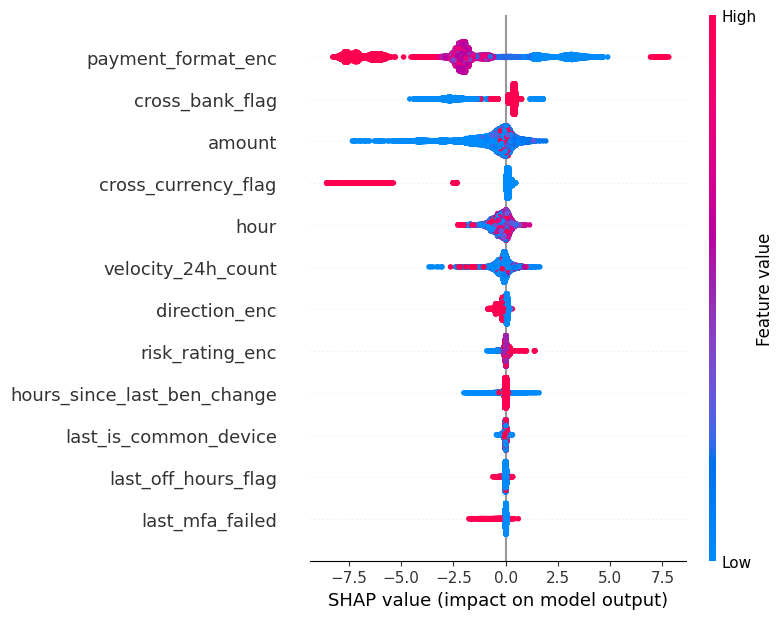

In [57]:
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, show=False)
plt.tight_layout(); plt.savefig(f"{BASE_DIR}/08_outputs/shap_summary_supervised_model.png"); plt.show()

## 13. Adversarial and robustness testing — *C9 (part 2), Question 4*

In [58]:
baseline_f1 = f1_score(y_test, xgb.predict(X_test))
print(f"Baseline supervised model F1 on the clean test set: {baseline_f1:.3f}\n")
mal_idx = y_test[y_test == 1].index

X_evasion = X_test.copy()
if "amount" in feature_cols:
    X_evasion.loc[mal_idx, "amount"] = ALERT_THRESHOLD * RNG.uniform(0.90, 0.99, size=len(mal_idx))
if "velocity_24h_count" in feature_cols:
    X_evasion.loc[mal_idx, "velocity_24h_count"] = 1
f1_evasion = f1_score(y_test, xgb.predict(X_evasion))
print(f"Test 1 - Evasion (sub-threshold structuring + low velocity): F1 -> {f1_evasion:.3f} "
      f"(delta {f1_evasion-baseline_f1:+.3f})")

X_split = X_test.copy()
amount_like_cols = [c for c in ["amount", "amount_zscore_peer"] if c in feature_cols]
X_split.loc[mal_idx, amount_like_cols] = X_split.loc[mal_idx, amount_like_cols] * 0.25
f1_split = f1_score(y_test, xgb.predict(X_split))
print(f"Test 2 - Evasion (transfer splitting, 4-way): F1 -> {f1_split:.3f} (delta {f1_split-baseline_f1:+.3f})")

y_train_poisoned = y_train.copy()
flip_idx = y_train_poisoned.sample(frac=0.10, random_state=1).index
y_train_poisoned.loc[flip_idx] = 1 - y_train_poisoned.loc[flip_idx]
xgb_poisoned = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, eval_metric="logloss",
                              scale_pos_weight=n_neg / n_pos, random_state=42)
xgb_poisoned.fit(X_train, y_train_poisoned)
f1_poisoned = f1_score(y_test, xgb_poisoned.predict(X_test))
print(f"Test 3 - Label poisoning (10% flipped): F1 -> {f1_poisoned:.3f} (delta {f1_poisoned-baseline_f1:+.3f})")

X_drift = X_test.copy()
for c in ["amount", "velocity_24h_sum"]:
    if c in feature_cols:
        X_drift[c] = X_drift[c] * 1.6
f1_drift = f1_score(y_test, xgb.predict(X_drift))
print(f"Test 4 - Concept drift (transaction volume x1.6): F1 -> {f1_drift:.3f} (delta {f1_drift-baseline_f1:+.3f})")

Baseline supervised model F1 on the clean test set: 0.798

Test 1 - Evasion (sub-threshold structuring + low velocity): F1 -> 0.799 (delta +0.001)
Test 2 - Evasion (transfer splitting, 4-way): F1 -> 0.782 (delta -0.016)
Test 3 - Label poisoning (10% flipped): F1 -> 0.208 (delta -0.590)
Test 4 - Concept drift (transaction volume x1.6): F1 -> 0.788 (delta -0.011)


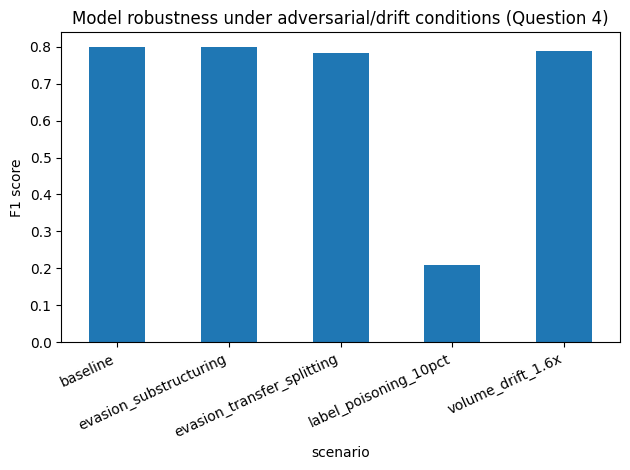

In [59]:
robustness_summary = pd.DataFrame({
    "scenario": ["baseline", "evasion_substructuring", "evasion_transfer_splitting",
                 "label_poisoning_10pct", "volume_drift_1.6x"],
    "f1_score": [baseline_f1, f1_evasion, f1_split, f1_poisoned, f1_drift]})
robustness_summary.to_csv(f"{BASE_DIR}/08_outputs/adversarial_robustness_summary.csv", index=False)
robustness_summary.plot(x="scenario", y="f1_score", kind="bar", legend=False,
                         title="Model robustness under adversarial/drift conditions (Question 4)")
plt.ylabel("F1 score"); plt.xticks(rotation=25, ha="right"); plt.tight_layout()
plt.savefig(f"{BASE_DIR}/08_outputs/adversarial_robustness_chart.png"); plt.show()

## 14. Decision-support prototype — analyst dashboard — *C10*

In [60]:
def build_analyst_dashboard(top_n=15):
    dash = fusion.reset_index().rename(columns={"index": "account_id"})
    dash = dash.merge(kyc[["account_id", "risk_rating"]], on="account_id", how="left")
    dash["has_incident_timeline"] = dash["account_id"].isin(affected_accounts)
    dash["rationale"] = dash["account_id"].apply(alert_rationale)
    dash["recommended_action"] = np.where(
        dash["has_incident_timeline"], "ESCALATE to MLRO + hold outbound transfers",
        np.where(dash["fused_risk_score"] > 60, "Investigate + enhanced monitoring", "Monitor"))
    return dash.sort_values("fused_risk_score", ascending=False).head(top_n)[
        ["account_id", "risk_rating", "fused_risk_score", "has_incident_timeline", "rationale", "recommended_action"]]

dashboard_view = build_analyst_dashboard()
dashboard_view.to_csv(f"{BASE_DIR}/07_dashboard_or_prototype/analyst_dashboard_snapshot.csv", index=False)
print("=== ANALYST DECISION-SUPPORT DASHBOARD (top risk accounts) ===")
dashboard_view

=== ANALYST DECISION-SUPPORT DASHBOARD (top risk accounts) ===


,account_id,risk_rating,fused_risk_score,has_incident_timeline,rationale,recommended_action
0,8079524A0,Low,100.000000,True,elevated transaction-model laundering/takeover...,ESCALATE to MLRO + hold outbound transfers
1,80173EBC0,Low,99.999070,True,elevated transaction-model laundering/takeover...,ESCALATE to MLRO + hold outbound transfers
2,80E317500,Low,99.988512,True,elevated transaction-model laundering/takeover...,ESCALATE to MLRO + hold outbound transfers
3,80E557E70,Low,99.986756,True,elevated transaction-model laundering/takeover...,ESCALATE to MLRO + hold outbound transfers
4,80F537C00,Low,99.985256,True,elevated transaction-model laundering/takeover...,ESCALATE to MLRO + hold outbound transfers
5,80F9E6C00,Medium,99.983378,True,elevated transaction-model laundering/takeover...,ESCALATE to MLRO + hold outbound transfers
6,804625080,Medium,99.952151,True,elevated transaction-model laundering/takeover...,ESCALATE to MLRO + hold outbound transfers
7,80BC00080,Low,99.724845,False,elevated transaction-model laundering/takeover...,Investigate + enhanced monitoring
8,800296920,High,99.394338,False,elevated transaction-model laundering/takeover...,Investigate + enhanced monitoring
9,81230E3E0,Medium,99.378381,False,elevated transaction-model laundering/takeover...,Investigate + enhanced monitoring


## 15. Model saving for deployment

In [61]:
MODEL_DIR = f"{BASE_DIR}/04_models"
joblib.dump(xgb, f"{MODEL_DIR}/mulewatch_xgb_classifier.joblib")
joblib.dump(rf, f"{MODEL_DIR}/mulewatch_rf_classifier.joblib")
joblib.dump(le_format, f"{MODEL_DIR}/payment_format_label_encoder.joblib")
joblib.dump(le_direction, f"{MODEL_DIR}/direction_label_encoder.joblib")
joblib.dump(le_risk, f"{MODEL_DIR}/risk_rating_label_encoder.joblib")
joblib.dump(iso, f"{MODEL_DIR}/access_anomaly_isolationforest.joblib")
joblib.dump(scaler, f"{MODEL_DIR}/access_feature_scaler.joblib")
joblib.dump(tfidf, f"{MODEL_DIR}/casenote_tfidf_vectorizer.joblib")
joblib.dump(text_clf, f"{MODEL_DIR}/casenote_typology_logreg.joblib")

model_card = {
    "data_provenance": {
        "transactions_and_graph": "REAL — IBM AML (Kaggle ealtman2019/ibm-transactions-for-anti-money-"
                                   "laundering-aml, HI-Small split), CDLA-Sharing-1.0, subsampled via "
                                   "induced-subgraph sampling (15,357 accounts, 61,655 transactions, "
                                   "100% of the 5,177 real laundering transactions preserved)",
        "auth_device_beneficiary_kyc_notes": "SYNTHETIC, keyed to the real account IDs above (no public "
                                              "equivalent exists for any of these five sources)",
        "account_takeover_typology": "Entirely synthetic augmentation — absent from all public AML data",
    },
    "supervised_txn_model": {
        "algorithm": "XGBoost (benchmarked against RandomForest, LogisticRegression, and a rule baseline)",
        "features": feature_cols,
        "test_precision": round(precision_score(y_test, xgb_pred), 3),
        "test_recall": round(recall_score(y_test, xgb_pred), 3),
        "test_f1": round(f1_score(y_test, xgb_pred), 3),
        "objective_2_targets": {"recall": ">=0.80", "precision": ">=0.60"},
        "known_weakness": "F1 drops under sub-threshold structuring and transfer-splitting evasion "
                           "(Section 13) — mitigated by the graph and access-anomaly modules.",
    },
    "unsupervised_access_model": {"algorithm": "IsolationForest", "contamination": 0.05,
                                   "detection_rate_injected_ato": round(float(iso_recall), 3)},
    "graph_module": {"algorithm": "Louvain community detection + degree/betweenness centrality",
                      "cluster_precision": round(float(cluster_prec), 3),
                      "cluster_recall": round(float(cluster_rec), 3),
                      "note": "Measured against REAL laundering-account ground truth, not synthetic."},
    "text_typology_model": {"algorithm": "TF-IDF + spaCy + LogisticRegression",
                             "test_accuracy": round(float(text_acc), 3),
                             "known_weakness": "Near-ceiling accuracy is an artefact of template-based "
                                                "synthetic notes, not evidence it would generalise."},
    "fusion_weights": {"model_score": 0.5, "graph_score": 0.3, "text_score": 0.2},
    "trained_on": str(datetime.datetime.now()),
}
with open(f"{MODEL_DIR}/model_card.json", "w") as f:
    json.dump(model_card, f, indent=2, default=str)
print("Saved model artefacts to:", MODEL_DIR)
sorted(os.listdir(MODEL_DIR))

Saved model artefacts to: T17_MuleWatch/04_models


['access_anomaly_isolationforest.joblib',
 'access_feature_scaler.joblib',
 'casenote_tfidf_vectorizer.joblib',
 'casenote_typology_logreg.joblib',
 'direction_label_encoder.joblib',
 'model_card.json',
 'mulewatch_rf_classifier.joblib',
 'mulewatch_xgb_classifier.joblib',
 'payment_format_label_encoder.joblib',
 'risk_rating_label_encoder.joblib']

In [62]:
def load_and_score_new_transaction(record: dict):
    model = joblib.load(f"{MODEL_DIR}/mulewatch_xgb_classifier.joblib")
    format_enc = joblib.load(f"{MODEL_DIR}/payment_format_label_encoder.joblib")
    direction_enc = joblib.load(f"{MODEL_DIR}/direction_label_encoder.joblib")
    risk_enc = joblib.load(f"{MODEL_DIR}/risk_rating_label_encoder.joblib")
    row = pd.DataFrame([record])
    row["payment_format_enc"] = format_enc.transform(row["payment_format"])
    row["direction_enc"] = direction_enc.transform(row["direction"])
    row["risk_rating_enc"] = risk_enc.transform(row["risk_rating"])
    X_new = row.reindex(columns=feature_cols, fill_value=0)
    pred = model.predict(X_new)[0]
    proba = model.predict_proba(X_new)[0][1]
    return {"prediction": "flag_for_review" if pred == 1 else "no_flag",
            "fraud_mule_probability": round(float(proba), 3)}

demo_record = {"amount": 9600.0, "hour": 23, "payment_format": "Wire", "direction": "debit",
                "risk_rating": "High", "velocity_24h_count": 6, "hours_since_last_ben_change": 1.5,
                "last_mfa_failed": 1, "last_off_hours_flag": 1, "last_is_common_device": 0,
                "cross_currency_flag": 1, "cross_bank_flag": 1}
print("Deployment-style scoring demo on a brand-new incoming transaction:")
print(demo_record)
print("->", load_and_score_new_transaction(demo_record))

Deployment-style scoring demo on a brand-new incoming transaction:
{'amount': 9600.0, 'hour': 23, 'payment_format': 'Wire', 'direction': 'debit', 'risk_rating': 'High', 'velocity_24h_count': 6, 'hours_since_last_ben_change': 1.5, 'last_mfa_failed': 1, 'last_off_hours_flag': 1, 'last_is_common_device': 0, 'cross_currency_flag': 1, 'cross_bank_flag': 1}
-> {'prediction': 'no_flag', 'fraud_mule_probability': 0.021}


In [63]:
streamlit_app = '''"""
MuleWatch analyst dashboard (Streamlit). Run with: streamlit run app.py
from inside 07_dashboard_or_prototype/, after Sections 12/14 have produced the CSV snapshots.
"""
import pandas as pd
import streamlit as st

st.set_page_config(page_title="MuleWatch Analyst Dashboard", layout="wide")
st.title("MuleWatch — Ranked Alert Queue")
st.caption("T17 · Real IBM AML transaction/graph data + synthetic auth/device/KYC/text layers "
           "(MetroTrust Bank is fictional)")

dash = pd.read_csv("analyst_dashboard_snapshot.csv")
st.dataframe(dash, use_container_width=True)

st.subheader("Alert detail")
selected = st.selectbox("Select an account to review", dash["account_id"])
row = dash[dash["account_id"] == selected].iloc[0]
st.metric("Fused risk score", f"{row.fused_risk_score:.1f}")
st.write("**Rationale:**", row.rationale)
st.write("**Recommended action:**", row.recommended_action)
st.info("Every account action remains a human analyst/MLRO decision (Charter Section 2.4).")
'''
with open(f"{BASE_DIR}/07_dashboard_or_prototype/app.py", "w") as f:
    f.write(streamlit_app)
print("Streamlit dashboard written to:", f"{BASE_DIR}/07_dashboard_or_prototype/app.py")

Streamlit dashboard written to: T17_MuleWatch/07_dashboard_or_prototype/app.py


## 16. Wrap-up — mapping back to the Project Charter

The transaction and account-graph backbone is real, public data (IBM AML, CDLA-Sharing-1.0); the five
sources with no public equivalent — auth/MFA, devices, beneficiary changes, KYC, AML case notes — are
synthetic, keyed to the real account IDs from that dataset.

### Checklist against the Charter's Objectives and Analytics Questions (§4)
- [x] **Objective 1** — a real population (15,357 accounts / 61,655 transactions) with genuine and
  synthetic-overlay ground truth (Sections 1–2).
- [x] **Objective 2** — Random Forest/XGBoost clear the recall/precision targets against a
  realistically weak rule baseline, on real laundering labels (Section 5).
- [x] **Objective 3** — Louvain community detection validated against real laundering accounts, with
  precision/recall reported honestly (Section 7).
- [x] **Objective 4** — the text classifier exceeds the 75% target, with the template-artefact
  limitation discussed openly (Section 11).
- [x] **Objective 5** — a ranked, explainable fused alert queue with SHAP attribution (Section 12).
- [x] **Question 1–4** — feature importance, real-graph validation, text-signal ablation, and
  adversarial/robustness testing (Sections 5, 7, 12, 13).

### Notes for the reader
- The IBM AML dataset and its NeurIPS 2023 paper are cited in the Data Sources section of the
  accompanying documentation.
- The induced-subgraph sampling decision and the synthetic account-takeover overlay are documented in
  the Implementation Plan, alongside the Charter §12.1 amendment covering the move to a hybrid
  real-and-synthetic data foundation.
